# Models evaluation - Test 1 (Synthetic Copy)

Hello! This notebook documents the code that was written to evalutate the models on different capabilities. We also include results of the evaluations. 

Here we will be testing the models on the synthetic copy test - the models are tasked with processing a text composed of N true and M noise tokens (the noise tokens are uniform), and then with outputting the N true tokens.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import random

# Build vocab for all models & tests. 
# We employ the same vocab size to be fair 

vocab = dict()

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ{.}()[]|"

for i in range(10):
    vocab[str(i)] = i

for char in characters:
    vocab[char] = len(vocab)

for i in range(100):
    vocab[f"NOISE_{i}"] = len(vocab)

vocab["<ENDSEQ>"] = len(vocab)
vocab["<STABLENOISE>"] = len(vocab)
vocab["<STARTTASK>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

In [3]:
def get_batch_ex2(batch_size, vocab, copy_size=5, buffer_size=50, device="cuda"):

    first_noise_ix = vocab["NOISE_0"]
    last_noise_ix = vocab["NOISE_99"]

    # Random noise
    noise_tensor = torch.randint(first_noise_ix, last_noise_ix + 1, (batch_size, buffer_size), device=device )

    # Random digits, sorted so they are increasing
    copy_tensor = torch.randint(0, 10, (batch_size, copy_size), device=device).sort(dim=-1).values

    # Choose positions for the digits.
    # Each row gets its own random positions.
    positions = (torch.rand(batch_size, buffer_size, device=device).argsort(dim=-1)[..., :copy_size].sort(dim=-1).values)

    # Put the digits into the noise
    ready_tensor = noise_tensor.clone()

    ready_tensor.scatter_(dim=-1, index=positions, src=copy_tensor)

    marker_tensor = torch.full(
        (batch_size, 1),
        vocab["<STARTTASK>"],
        device=device,
    )

    ready_tensor = torch.cat([ready_tensor, marker_tensor], dim=-1)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor

def evaluate_ex2(model, copy_size, buffer_size, total_batches, batch_size, vocab, teacher_forcing=True, diagnostic=False):

    print("Testing model at ", buffer_size, " buffer_size.")

    avg_difference_sum = 0
    with torch.no_grad():
        model.eval()
        for batch_num in trange(total_batches + 1): #We want to get to the end of the user-specified range.

            batch, targets = get_batch_ex2(batch_size, vocab, copy_size, buffer_size) #targets = (batch, seq)

                
            model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

            if teacher_forcing==False:
                logits = model.predict_inference(
                    x=batch,
                    vocab=vocab,
                    max_len=copy_size-1
                )
            else:
                logits = model.forward(batch, model_targets) # (batch, seq, emb)

            tokens = torch.argmax(logits, dim=2) # (batch, seq)

            difference = targets - tokens #we'll get some number where the numbers are not the same

            difference = (difference !=0).float()

            num_elements = copy_size * batch_size

            num_different = torch.sum(difference)

            avg_difference = num_different / num_elements

            avg_difference_sum = avg_difference_sum + avg_difference.item()

            if diagnostic==True and batch_num == total_batches:
                print("True targets: ", targets)
                print("Predictions: ", tokens)

        model.train()

    return avg_difference_sum / (total_batches+1)



In [4]:

def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} Sequential noise filtering task')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)

def run_training_ex2(model, batch_size, total_batches, test_batches, copy_size, buffer_size, opt, test_break, model_name,
                     steps_history, train_history, test_history, vocab):
    training_loss = 0

    for batch_num in trange(total_batches + 1):

        act_buffer_size = random.randint(100, buffer_size)

        batch, targets = get_batch_ex2(batch_size, vocab, copy_size, act_buffer_size)

        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        #print(model_targets.shape)

        opt.zero_grad()

        logits = model.forward(batch, model_targets)
        loss_t = F.cross_entropy(logits.transpose(1, 2), targets)

        loss_t.backward()

        opt.step()

        training_loss = training_loss + loss_t.item()

        if batch_num % 1000 == 0 and batch_num != 0:
            save_model(model, opt, epoch_saved=batch_num, model_name=model_name, note="ex2")

        if batch_num % test_break == 0:

            with torch.no_grad():
                total_loss = 0
                avg_training_loss = training_loss / test_break
                training_loss = 0

                model.eval()

                for test_batch_num in trange(test_batches):
                    batch, targets = get_batch_ex2(batch_size, vocab, copy_size, buffer_size)
                    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()
                    logits = model.forward(batch, model_targets)
                    loss_t = F.cross_entropy(logits.transpose(1,2), targets)
                    total_loss = total_loss + loss_t.item()

                model.train()

                avg_testing_loss = total_loss / test_batches

                steps_history.append(batch_num)
                train_history.append(avg_training_loss)
                test_history.append(avg_testing_loss)

                plot_loss_curves(steps_history, train_history, test_history, model_name=model_name)

                print(f"STEP: {batch_num} | TRAIN LOSS: {avg_training_loss:.4f} | TEST LOSS: {avg_testing_loss:.4f}")


## Training

After code definition, we train the models.

In [5]:
import custom_models

hid=256
m_hid=16
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []

device = "cuda"

sLSTM_model = custom_models.sLSTM(hid, emb, device="cuda")
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)

MGU_model = custom_models.MRRN(hid, emb, device="cuda")
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)

GRU_model = custom_models.CopyGRU(hid, emb, device="cuda")
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)

maGRU_model = custom_models.maGRU(hid, emb, device="cuda")
opt_maGRU = torch.optim.Adam(maGRU_model.parameters(), lr=lr)

eGRU_model = custom_models.eGRU(hid, emb, device="cuda")
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

mLSTM_model = custom_models.mLSTM(m_hid, emb, device=device)
opt_mLSTM = torch.optim.Adam(mLSTM_model.parameters(), lr=lr)

mLSTMLite_model = custom_models.mLSTMLite(m_hid, emb, device=device)
opt_mLSTMLite = torch.optim.Adam(mLSTMLite_model.parameters(), lr=lr)

LSTM_model = custom_models.CopyLSTM(hid, emb, device="cuda")
opt_LSTM = torch.optim.Adam(LSTM_model.parameters(), lr=lr)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

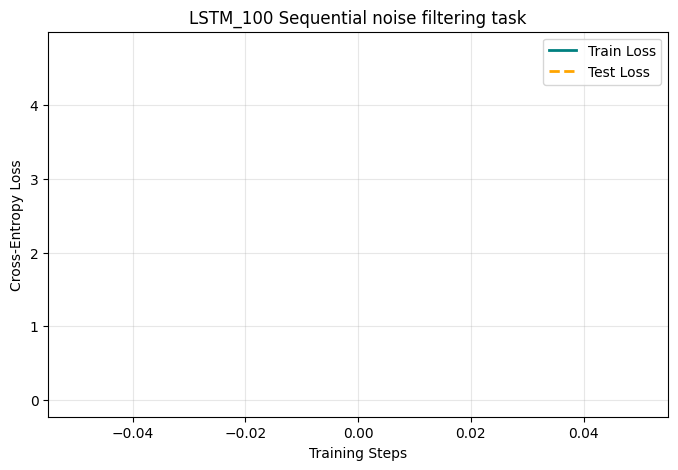

STEP: 0 | TRAIN LOSS: 0.0099 | TEST LOSS: 4.7593


  0%|          | 0/10 [00:00<?, ?it/s]

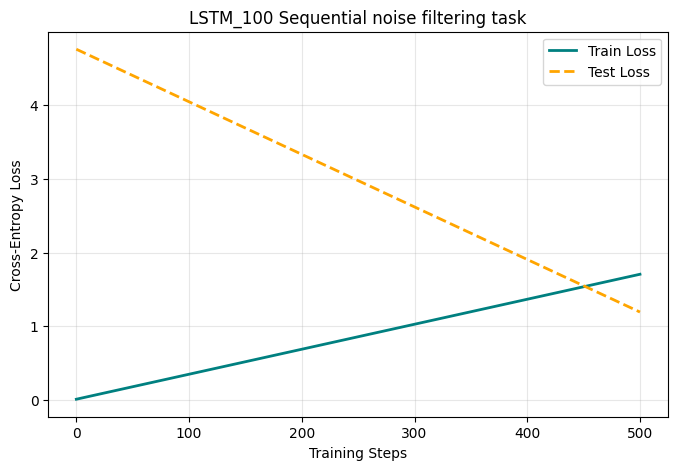

STEP: 500 | TRAIN LOSS: 1.7056 | TEST LOSS: 1.1928


  0%|          | 0/10 [00:00<?, ?it/s]

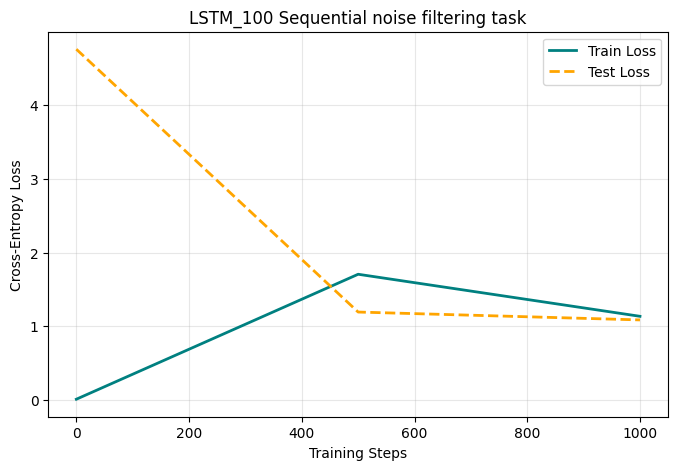

STEP: 1000 | TRAIN LOSS: 1.1351 | TEST LOSS: 1.0860


  0%|          | 0/10 [00:00<?, ?it/s]

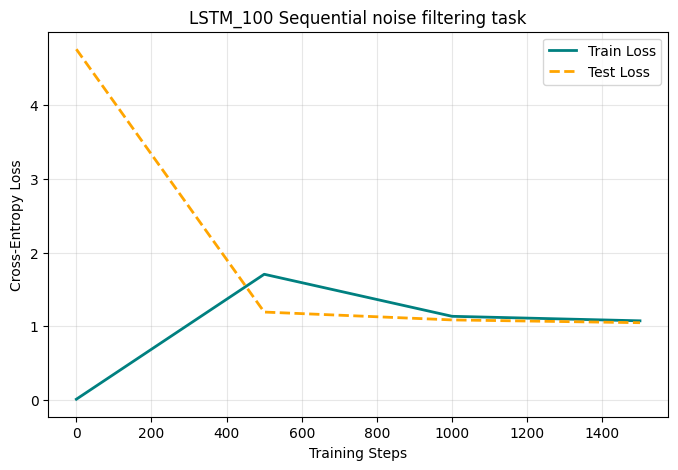

STEP: 1500 | TRAIN LOSS: 1.0738 | TEST LOSS: 1.0482


  0%|          | 0/10 [00:00<?, ?it/s]

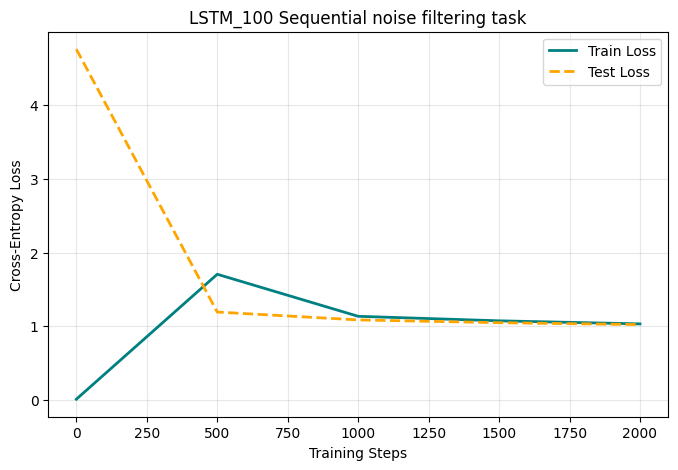

STEP: 2000 | TRAIN LOSS: 1.0321 | TEST LOSS: 1.0226


  0%|          | 0/10 [00:00<?, ?it/s]

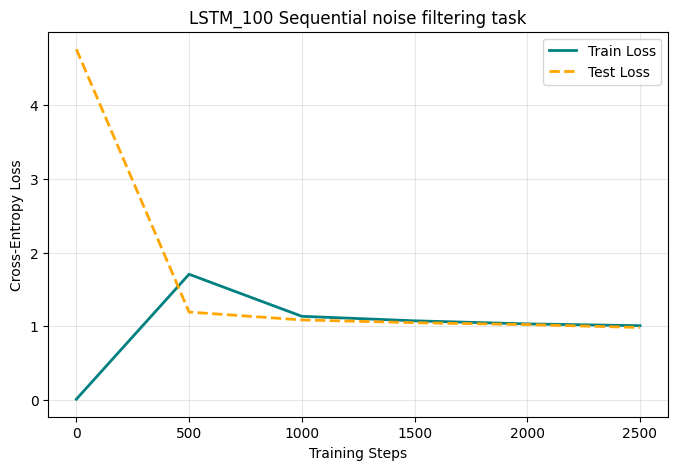

STEP: 2500 | TRAIN LOSS: 1.0080 | TEST LOSS: 0.9835


  0%|          | 0/10 [00:00<?, ?it/s]

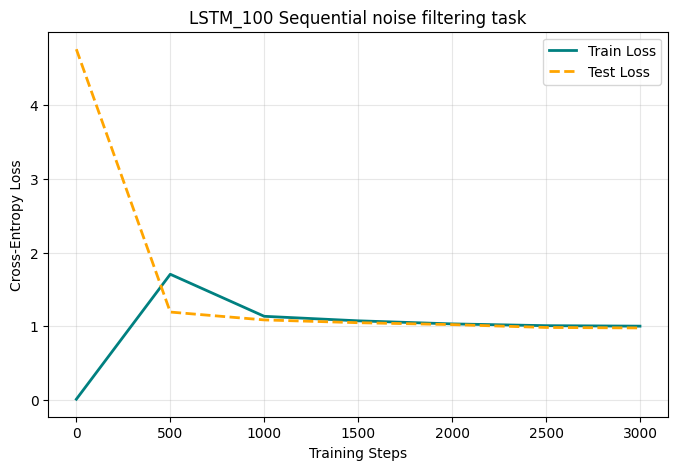

STEP: 3000 | TRAIN LOSS: 1.0015 | TEST LOSS: 0.9773


  0%|          | 0/10 [00:00<?, ?it/s]

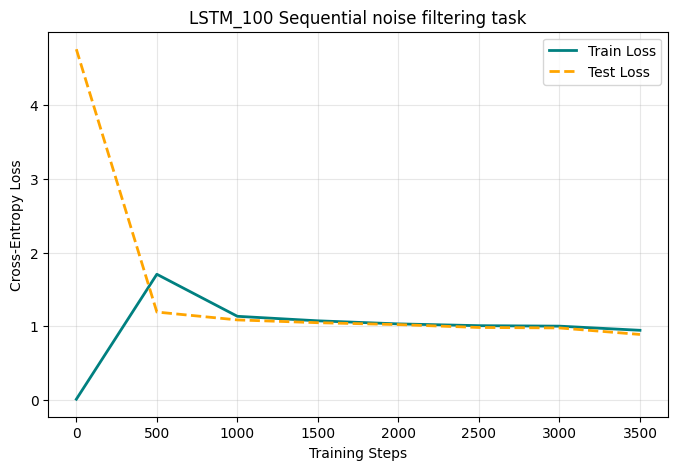

STEP: 3500 | TRAIN LOSS: 0.9452 | TEST LOSS: 0.8887


  0%|          | 0/10 [00:00<?, ?it/s]

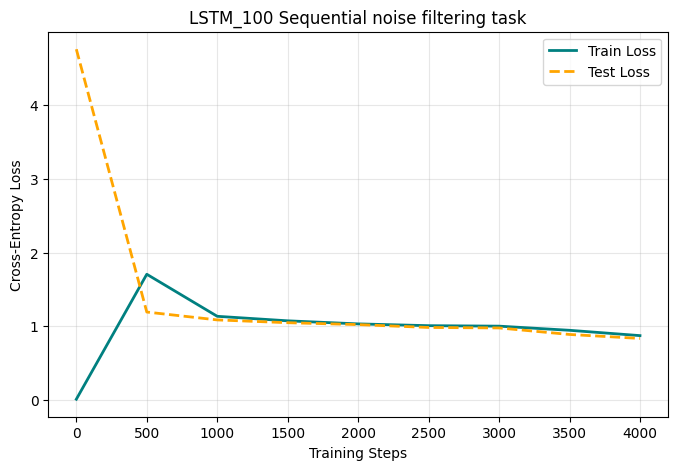

STEP: 4000 | TRAIN LOSS: 0.8730 | TEST LOSS: 0.8347


  0%|          | 0/10 [00:00<?, ?it/s]

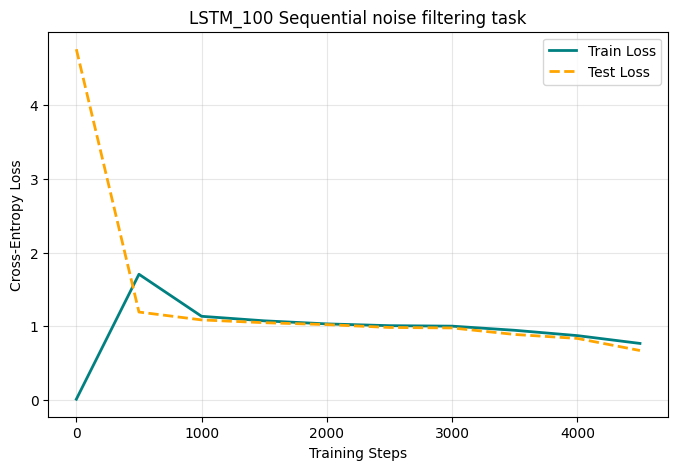

STEP: 4500 | TRAIN LOSS: 0.7670 | TEST LOSS: 0.6707


  0%|          | 0/10 [00:00<?, ?it/s]

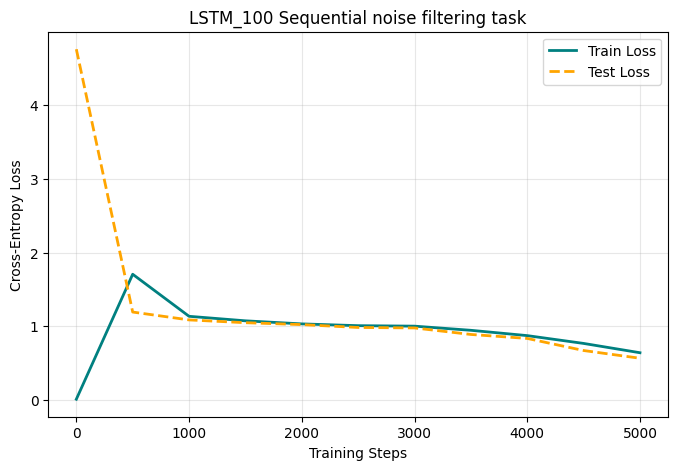

STEP: 5000 | TRAIN LOSS: 0.6407 | TEST LOSS: 0.5659


  0%|          | 0/10 [00:00<?, ?it/s]

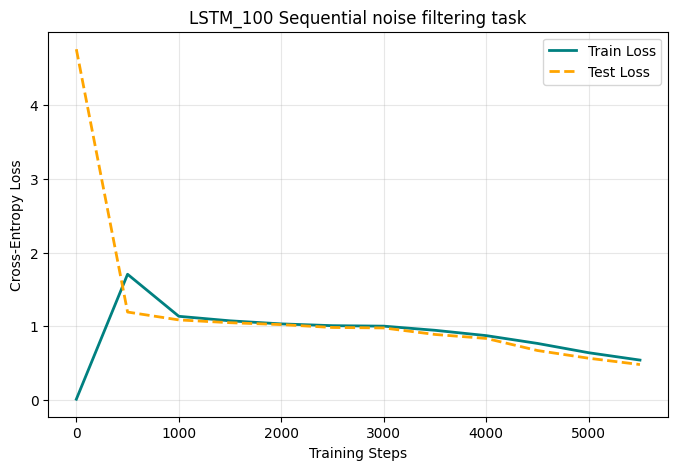

STEP: 5500 | TRAIN LOSS: 0.5409 | TEST LOSS: 0.4804


  0%|          | 0/10 [00:00<?, ?it/s]

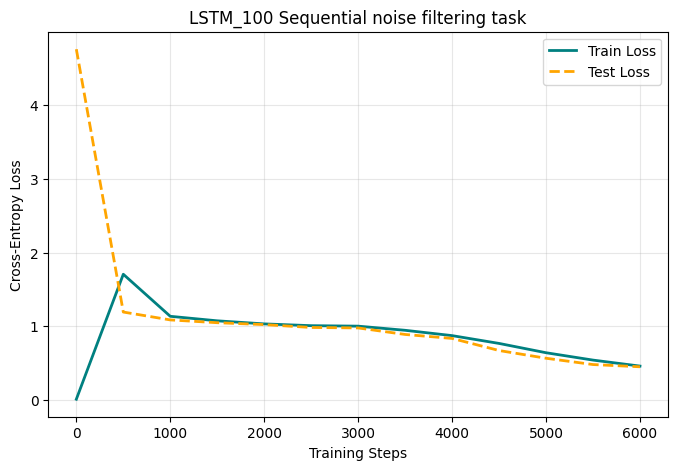

STEP: 6000 | TRAIN LOSS: 0.4594 | TEST LOSS: 0.4500


  0%|          | 0/10 [00:00<?, ?it/s]

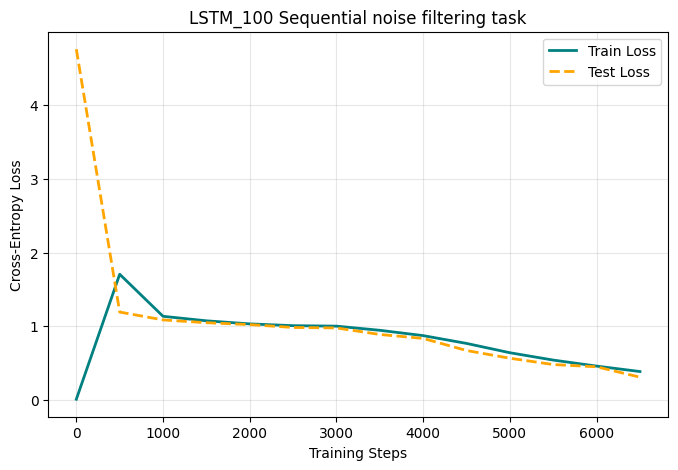

STEP: 6500 | TRAIN LOSS: 0.3855 | TEST LOSS: 0.3091


  0%|          | 0/10 [00:00<?, ?it/s]

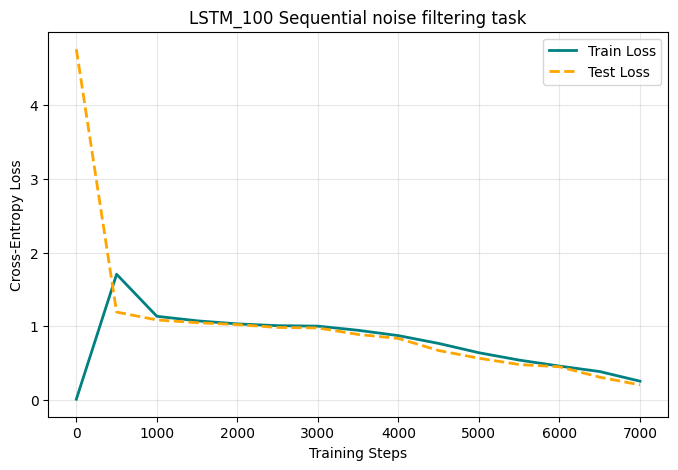

STEP: 7000 | TRAIN LOSS: 0.2547 | TEST LOSS: 0.2043


In [6]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(model=LSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 copy_size=copy_size,
                 buffer_size=buffer_size, 
                 opt=opt_LSTM, 
                 test_break=500, 
                 model_name="LSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

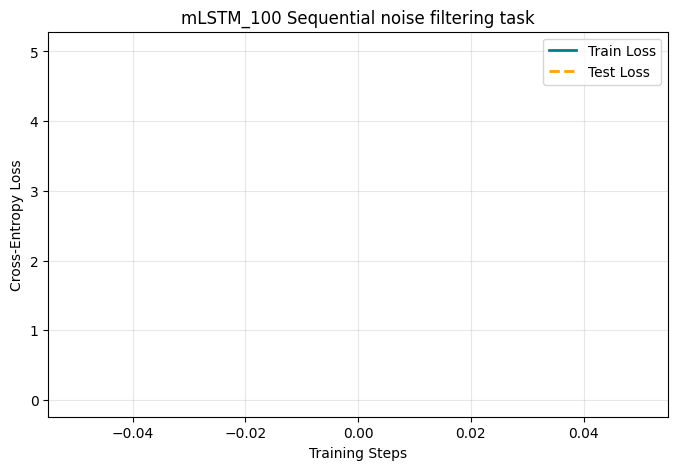

STEP: 0 | TRAIN LOSS: 0.0101 | TEST LOSS: 5.0311


  0%|          | 0/10 [00:00<?, ?it/s]

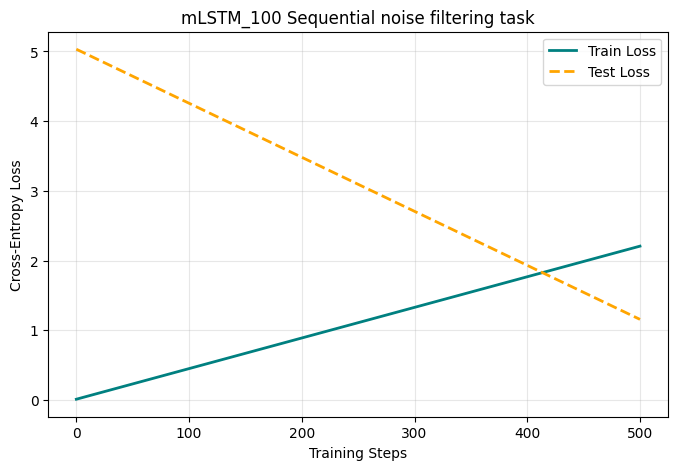

STEP: 500 | TRAIN LOSS: 2.2061 | TEST LOSS: 1.1555


  0%|          | 0/10 [00:00<?, ?it/s]

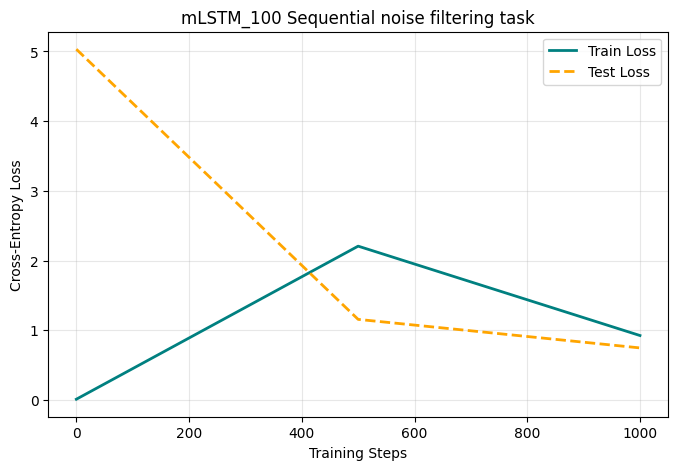

STEP: 1000 | TRAIN LOSS: 0.9239 | TEST LOSS: 0.7462


  0%|          | 0/10 [00:00<?, ?it/s]

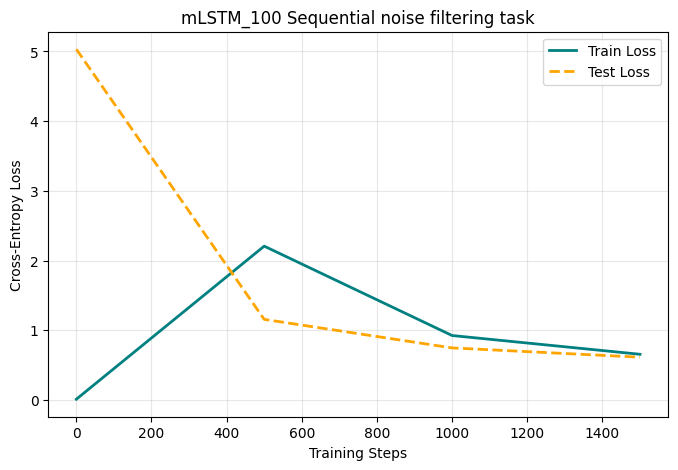

STEP: 1500 | TRAIN LOSS: 0.6548 | TEST LOSS: 0.6127


  0%|          | 0/10 [00:00<?, ?it/s]

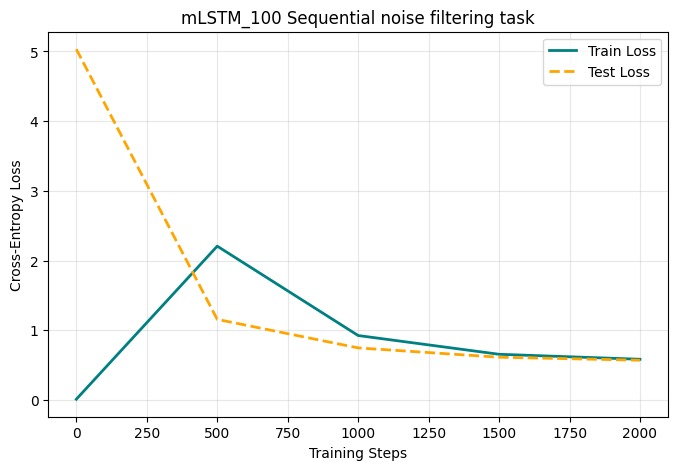

STEP: 2000 | TRAIN LOSS: 0.5833 | TEST LOSS: 0.5694


  0%|          | 0/10 [00:00<?, ?it/s]

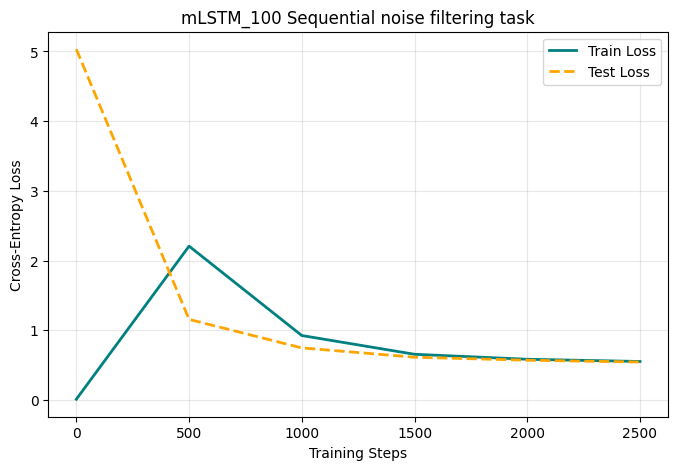

STEP: 2500 | TRAIN LOSS: 0.5514 | TEST LOSS: 0.5436


  0%|          | 0/10 [00:00<?, ?it/s]

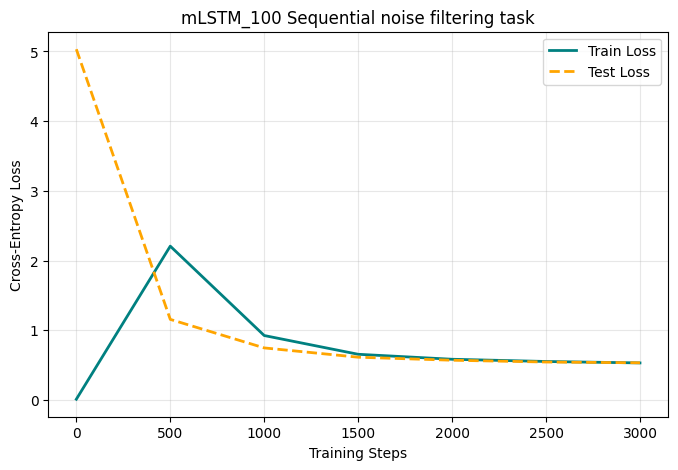

STEP: 3000 | TRAIN LOSS: 0.5308 | TEST LOSS: 0.5328


  0%|          | 0/10 [00:00<?, ?it/s]

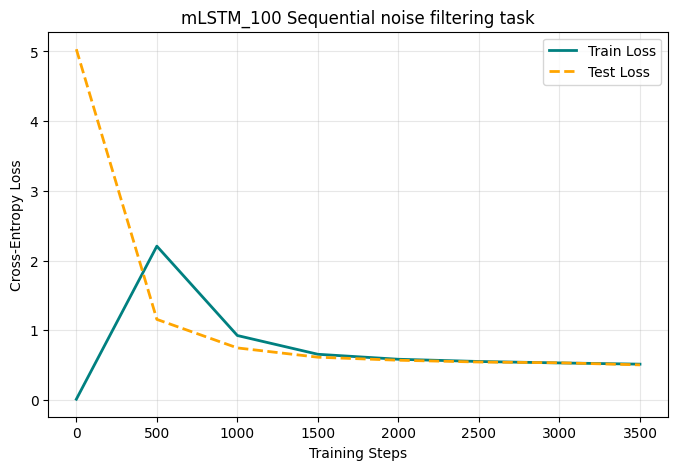

STEP: 3500 | TRAIN LOSS: 0.5130 | TEST LOSS: 0.5028


  0%|          | 0/10 [00:00<?, ?it/s]

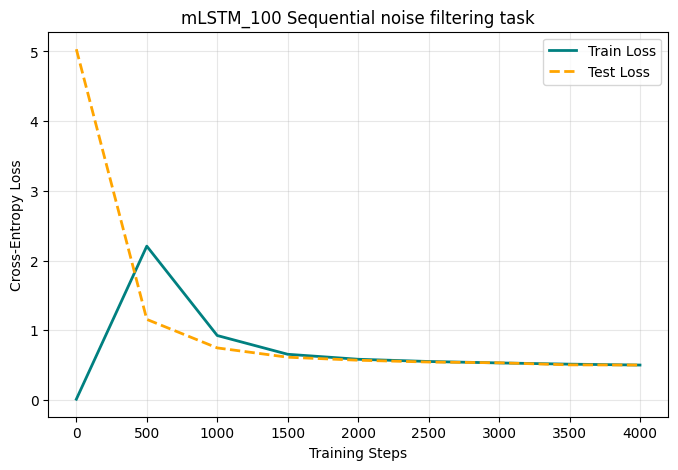

STEP: 4000 | TRAIN LOSS: 0.5003 | TEST LOSS: 0.5005


  0%|          | 0/10 [00:00<?, ?it/s]

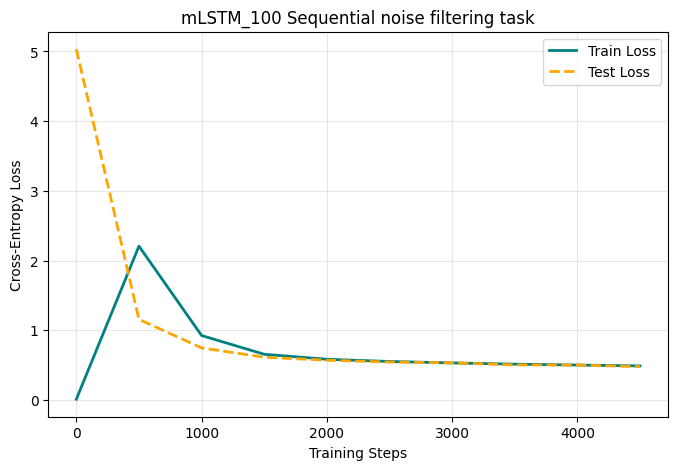

STEP: 4500 | TRAIN LOSS: 0.4878 | TEST LOSS: 0.4777


  0%|          | 0/10 [00:00<?, ?it/s]

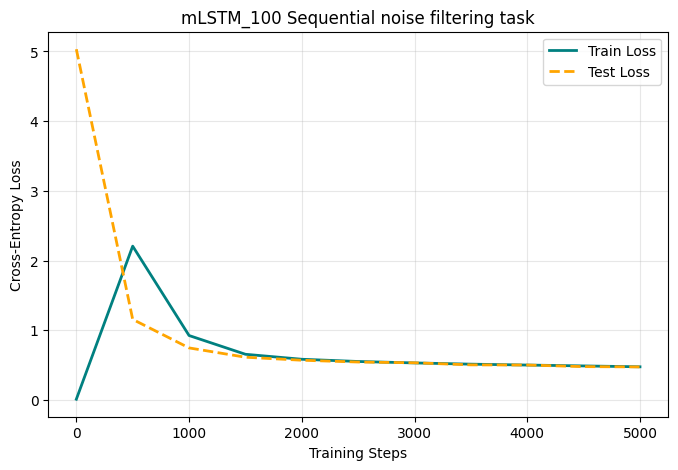

STEP: 5000 | TRAIN LOSS: 0.4752 | TEST LOSS: 0.4735


  0%|          | 0/10 [00:00<?, ?it/s]

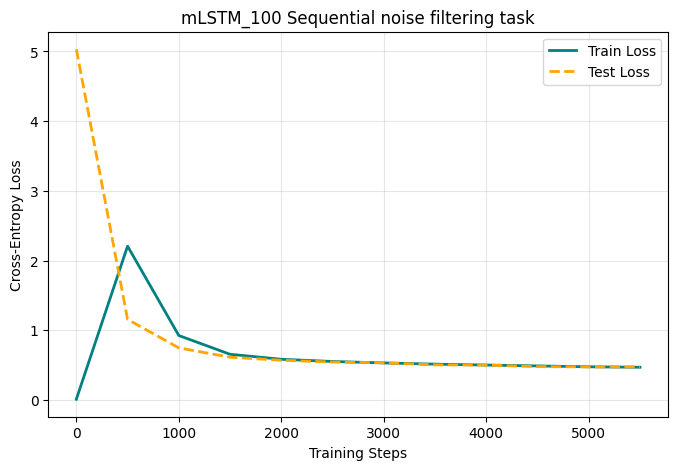

STEP: 5500 | TRAIN LOSS: 0.4690 | TEST LOSS: 0.4746


  0%|          | 0/10 [00:00<?, ?it/s]

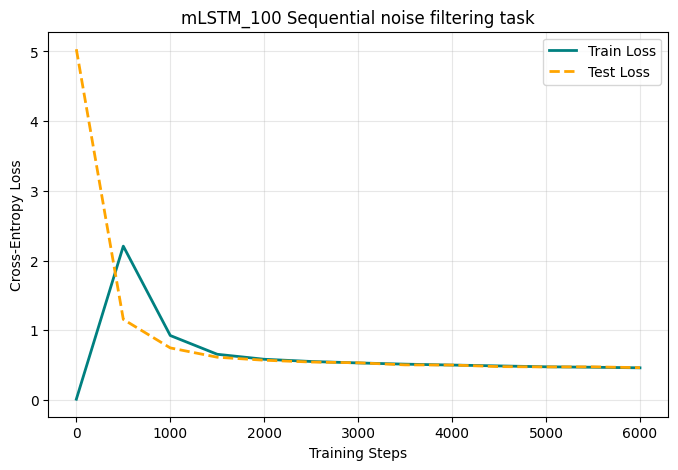

STEP: 6000 | TRAIN LOSS: 0.4604 | TEST LOSS: 0.4630


  0%|          | 0/10 [00:00<?, ?it/s]

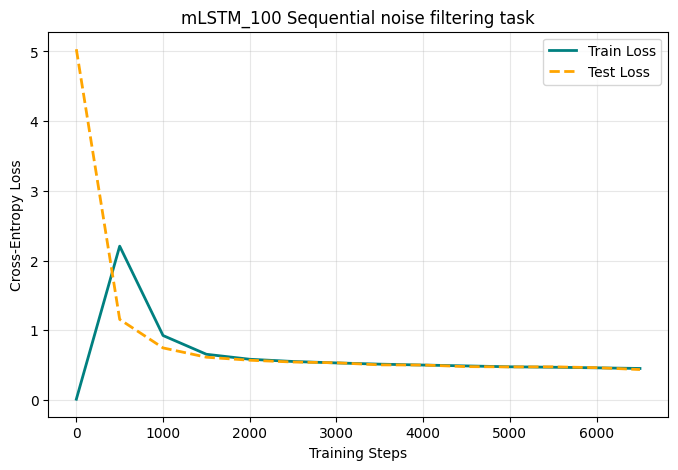

STEP: 6500 | TRAIN LOSS: 0.4513 | TEST LOSS: 0.4358


  0%|          | 0/10 [00:00<?, ?it/s]

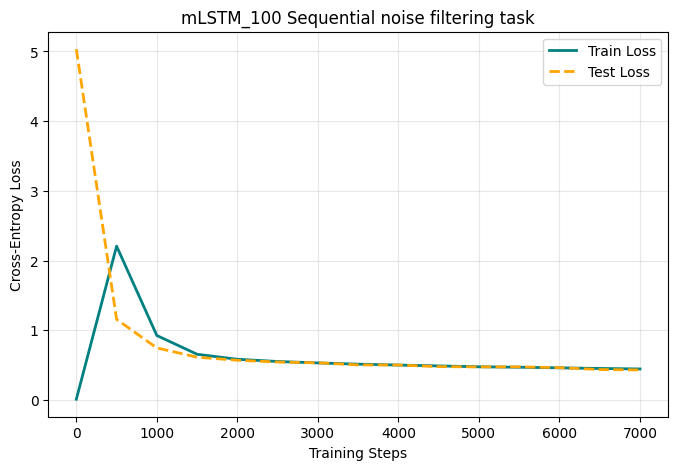

STEP: 7000 | TRAIN LOSS: 0.4441 | TEST LOSS: 0.4302


In [5]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(model=mLSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 copy_size=copy_size,
                 buffer_size=buffer_size, 
                 opt=opt_mLSTM, 
                 test_break=500, 
                 model_name="mLSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

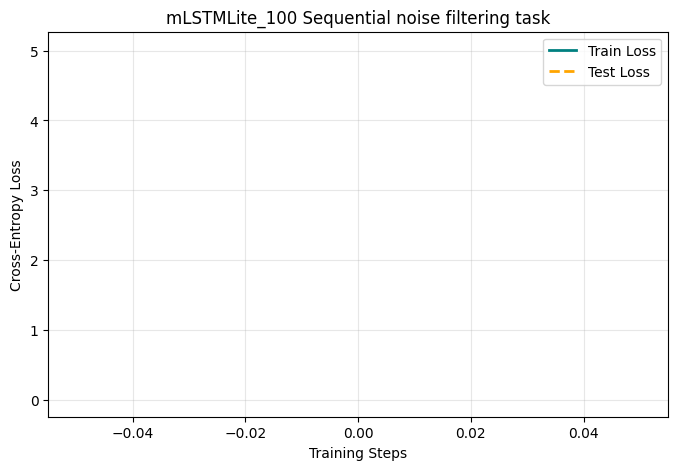

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 5.0186


  0%|          | 0/10 [00:00<?, ?it/s]

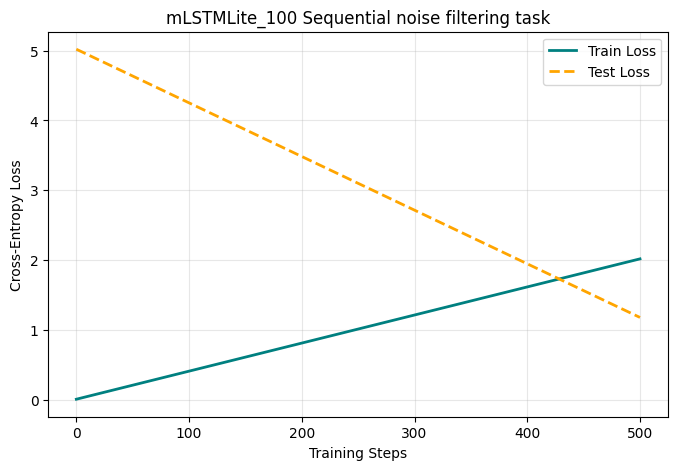

STEP: 500 | TRAIN LOSS: 2.0186 | TEST LOSS: 1.1803


  0%|          | 0/10 [00:00<?, ?it/s]

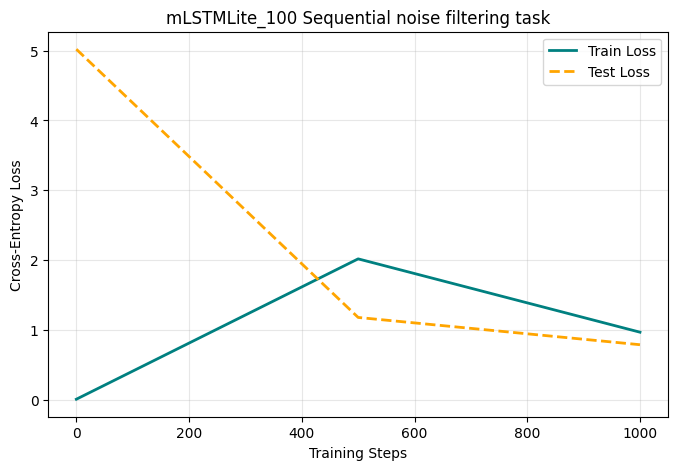

STEP: 1000 | TRAIN LOSS: 0.9692 | TEST LOSS: 0.7900


  0%|          | 0/10 [00:00<?, ?it/s]

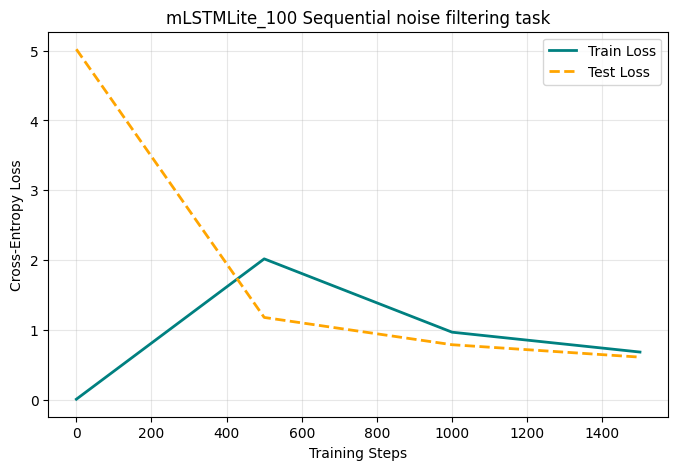

STEP: 1500 | TRAIN LOSS: 0.6850 | TEST LOSS: 0.6123


  0%|          | 0/10 [00:00<?, ?it/s]

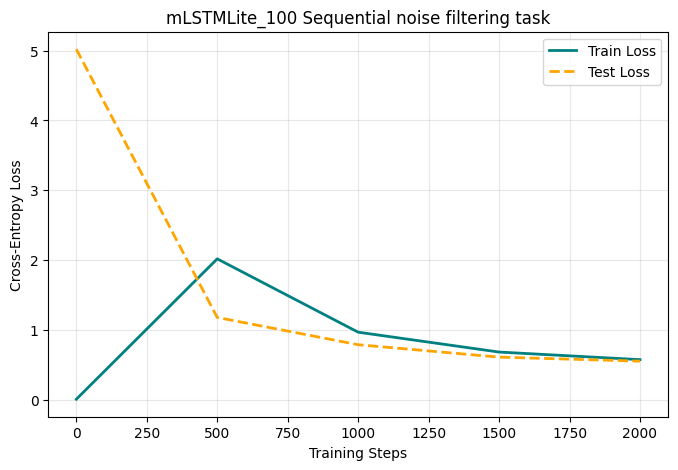

STEP: 2000 | TRAIN LOSS: 0.5764 | TEST LOSS: 0.5547


  0%|          | 0/10 [00:00<?, ?it/s]

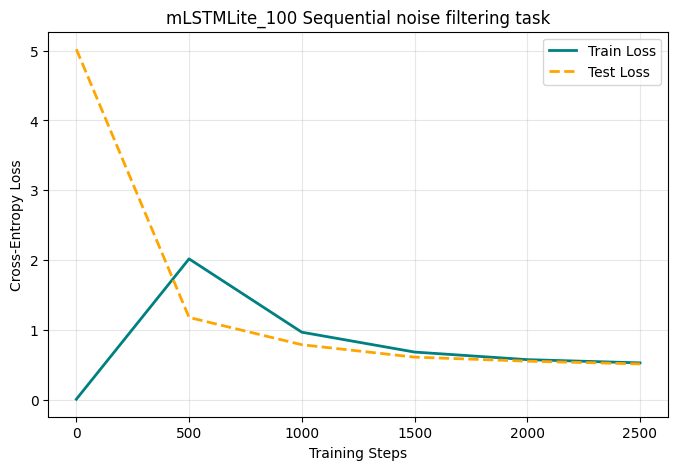

STEP: 2500 | TRAIN LOSS: 0.5302 | TEST LOSS: 0.5151


  0%|          | 0/10 [00:00<?, ?it/s]

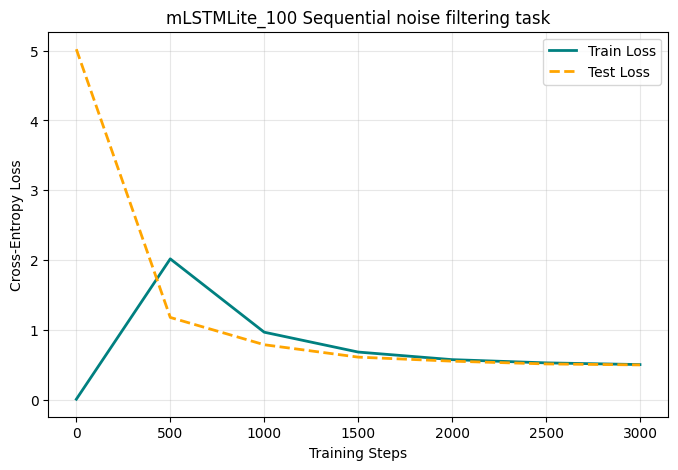

STEP: 3000 | TRAIN LOSS: 0.5058 | TEST LOSS: 0.5009


  0%|          | 0/10 [00:00<?, ?it/s]

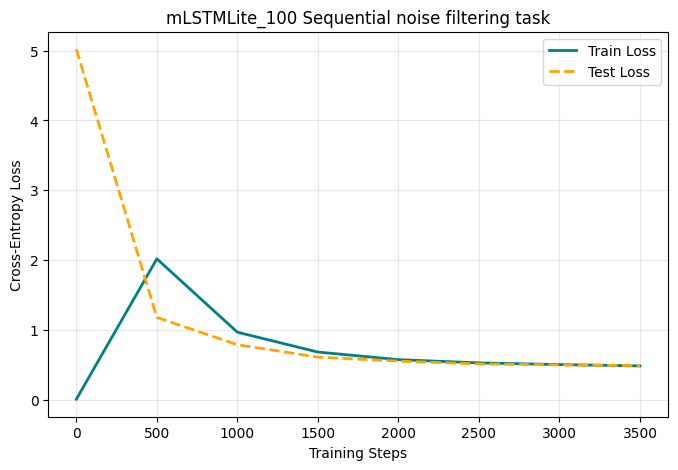

STEP: 3500 | TRAIN LOSS: 0.4865 | TEST LOSS: 0.4915


  0%|          | 0/10 [00:00<?, ?it/s]

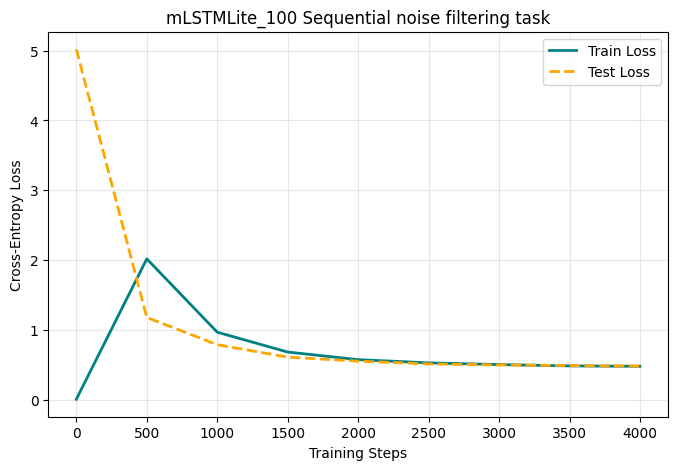

STEP: 4000 | TRAIN LOSS: 0.4814 | TEST LOSS: 0.4841


  0%|          | 0/10 [00:00<?, ?it/s]

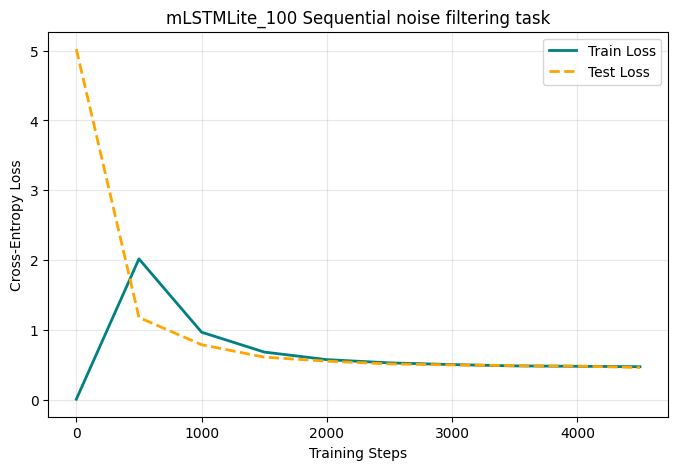

STEP: 4500 | TRAIN LOSS: 0.4751 | TEST LOSS: 0.4630


  0%|          | 0/10 [00:00<?, ?it/s]

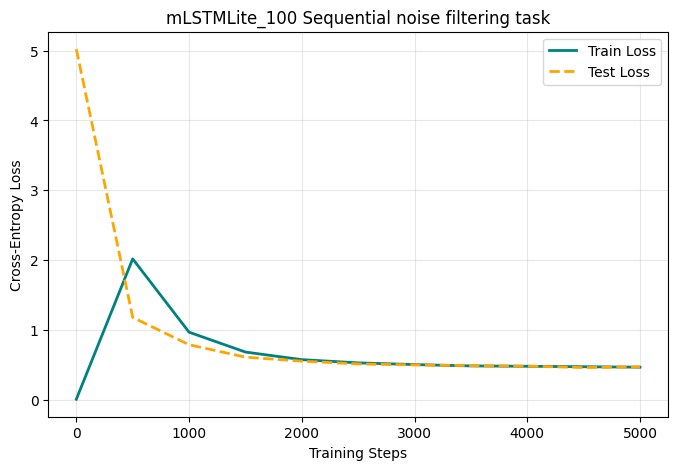

STEP: 5000 | TRAIN LOSS: 0.4687 | TEST LOSS: 0.4734


  0%|          | 0/10 [00:00<?, ?it/s]

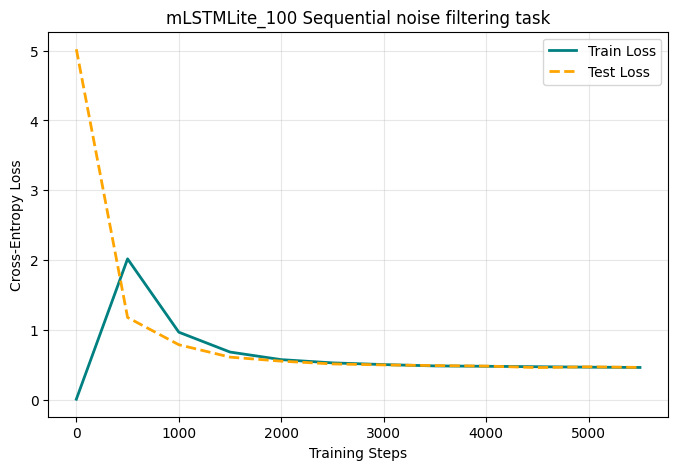

STEP: 5500 | TRAIN LOSS: 0.4645 | TEST LOSS: 0.4656


  0%|          | 0/10 [00:00<?, ?it/s]

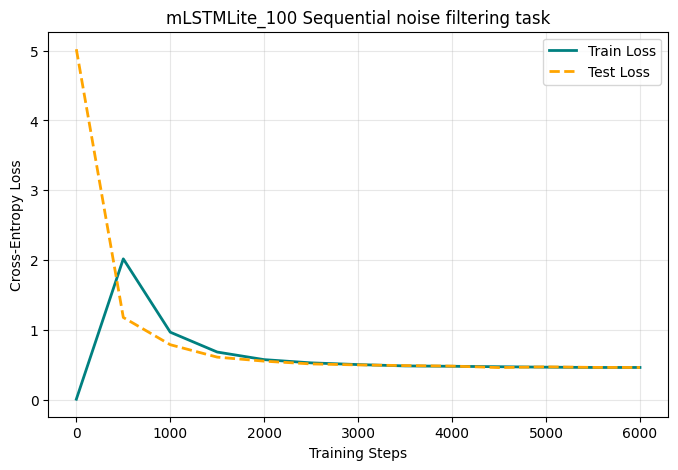

STEP: 6000 | TRAIN LOSS: 0.4645 | TEST LOSS: 0.4644


  0%|          | 0/10 [00:00<?, ?it/s]

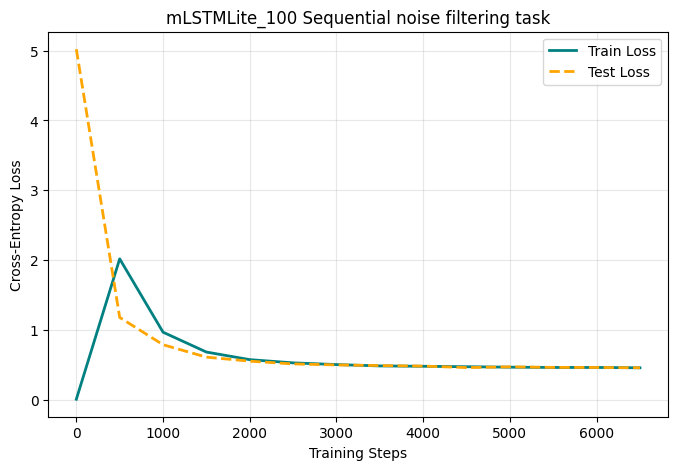

STEP: 6500 | TRAIN LOSS: 0.4598 | TEST LOSS: 0.4601


  0%|          | 0/10 [00:00<?, ?it/s]

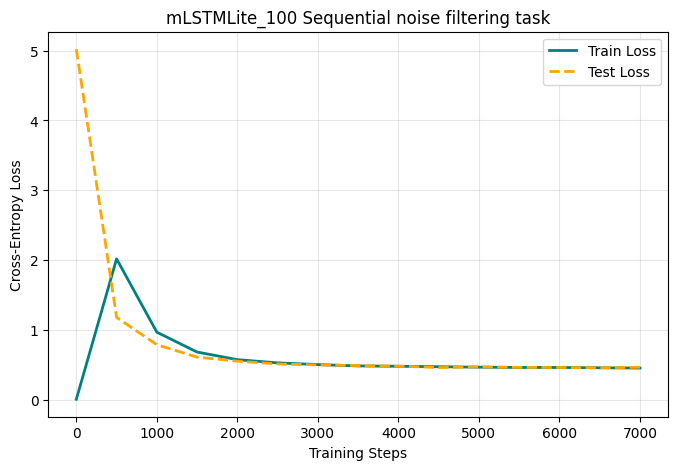

STEP: 7000 | TRAIN LOSS: 0.4562 | TEST LOSS: 0.4675


In [6]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(model=mLSTMLite_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 copy_size=copy_size,
                 buffer_size=buffer_size, 
                 opt=opt_mLSTMLite, 
                 test_break=500, 
                 model_name="mLSTMLite_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

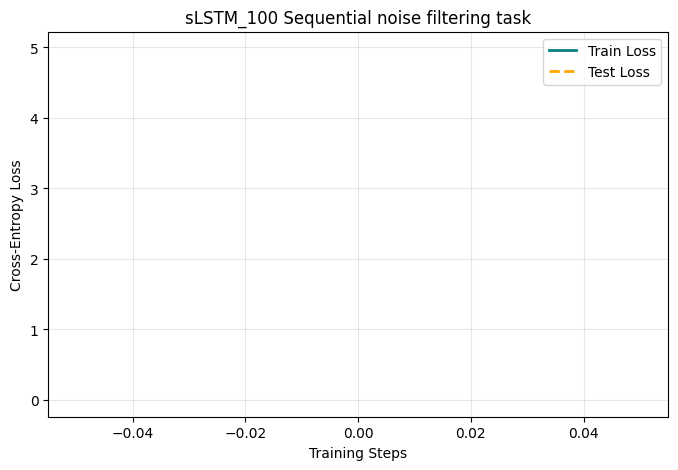

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9747


  0%|          | 0/10 [00:00<?, ?it/s]

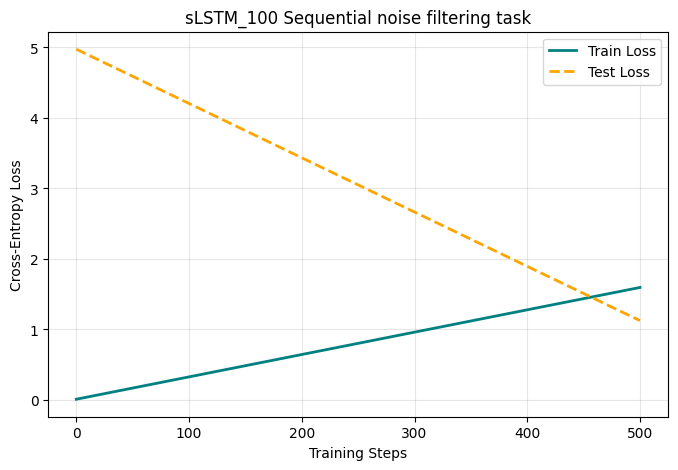

STEP: 500 | TRAIN LOSS: 1.5953 | TEST LOSS: 1.1248


  0%|          | 0/10 [00:00<?, ?it/s]

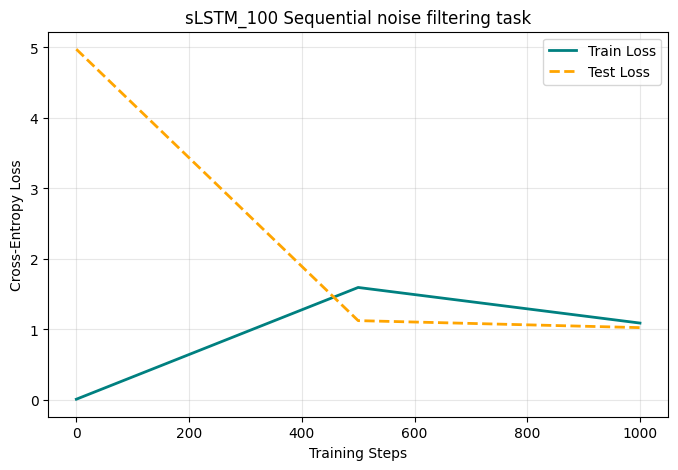

STEP: 1000 | TRAIN LOSS: 1.0902 | TEST LOSS: 1.0256


  0%|          | 0/10 [00:00<?, ?it/s]

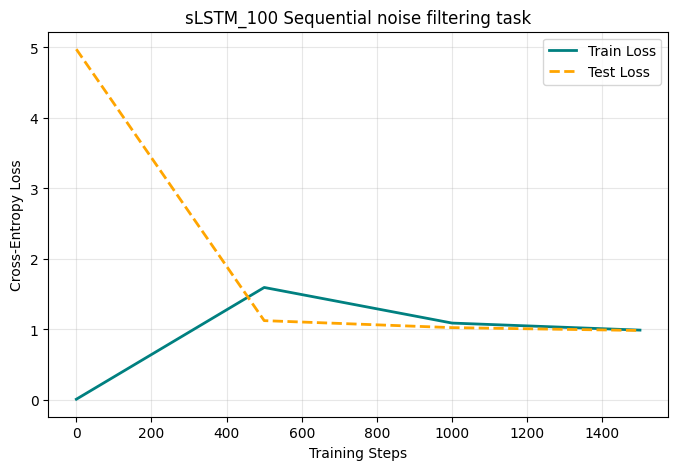

STEP: 1500 | TRAIN LOSS: 0.9903 | TEST LOSS: 0.9850


  0%|          | 0/10 [00:00<?, ?it/s]

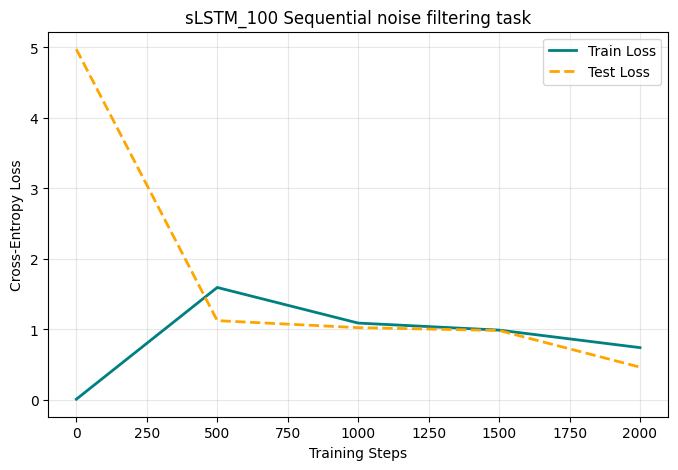

STEP: 2000 | TRAIN LOSS: 0.7418 | TEST LOSS: 0.4649


  0%|          | 0/10 [00:00<?, ?it/s]

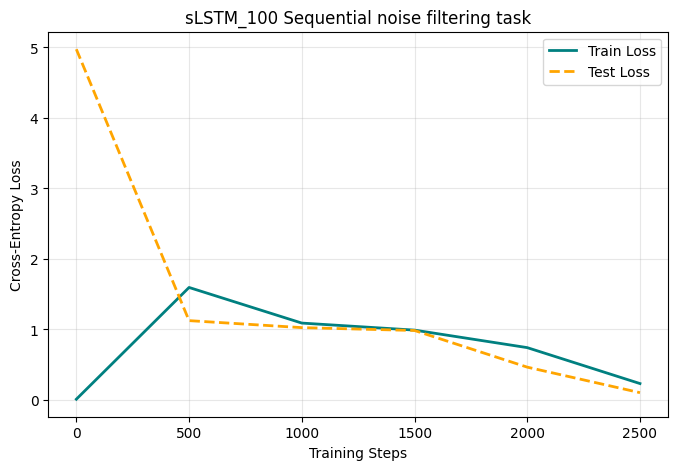

STEP: 2500 | TRAIN LOSS: 0.2322 | TEST LOSS: 0.1029


  0%|          | 0/10 [00:00<?, ?it/s]

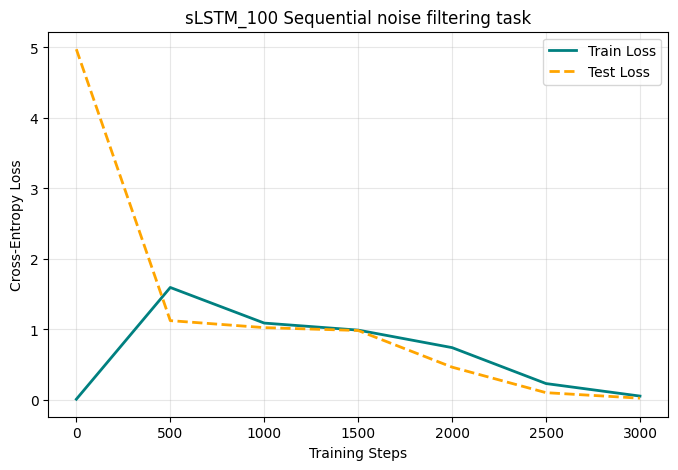

STEP: 3000 | TRAIN LOSS: 0.0545 | TEST LOSS: 0.0248


  0%|          | 0/10 [00:00<?, ?it/s]

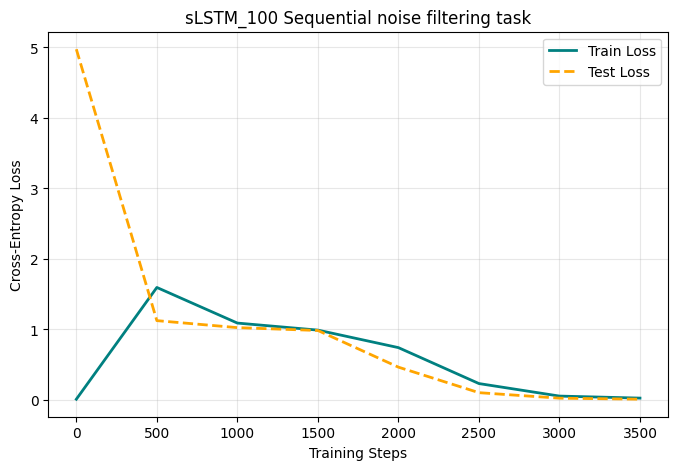

STEP: 3500 | TRAIN LOSS: 0.0259 | TEST LOSS: 0.0103


  0%|          | 0/10 [00:00<?, ?it/s]

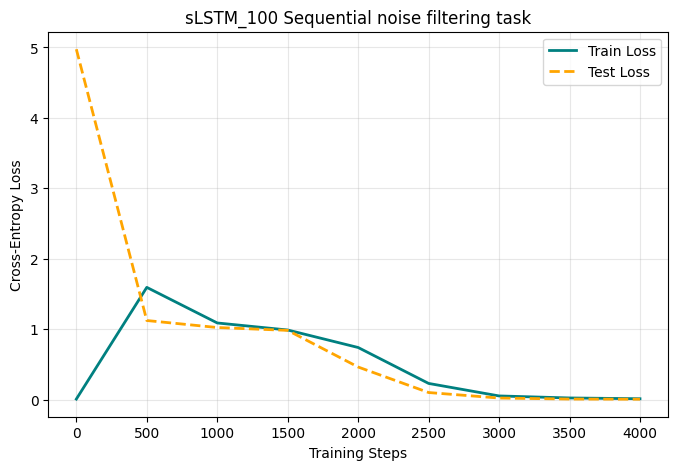

STEP: 4000 | TRAIN LOSS: 0.0149 | TEST LOSS: 0.0080


  0%|          | 0/10 [00:00<?, ?it/s]

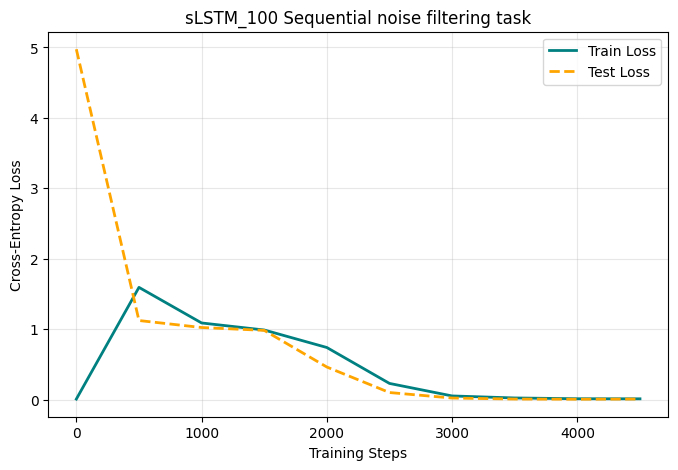

STEP: 4500 | TRAIN LOSS: 0.0139 | TEST LOSS: 0.0103


  0%|          | 0/10 [00:00<?, ?it/s]

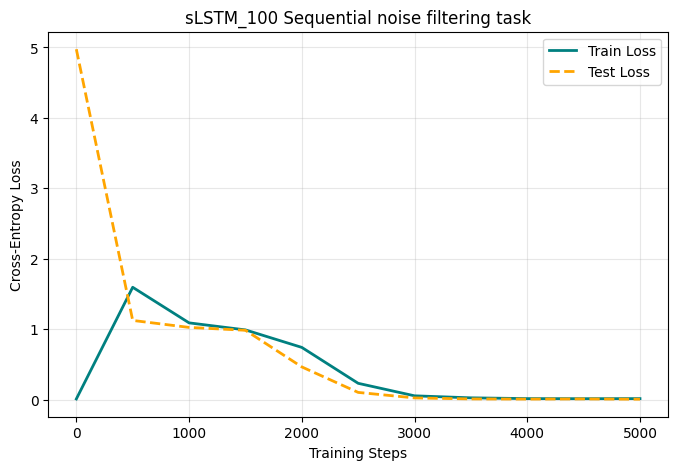

STEP: 5000 | TRAIN LOSS: 0.0150 | TEST LOSS: 0.0062


  0%|          | 0/10 [00:00<?, ?it/s]

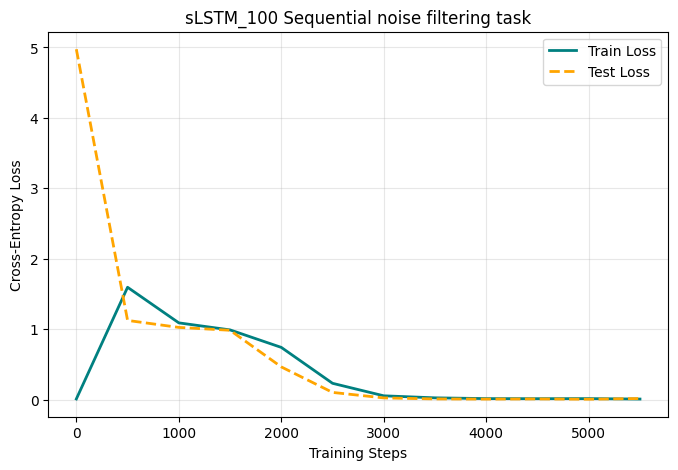

STEP: 5500 | TRAIN LOSS: 0.0086 | TEST LOSS: 0.0161


  0%|          | 0/10 [00:00<?, ?it/s]

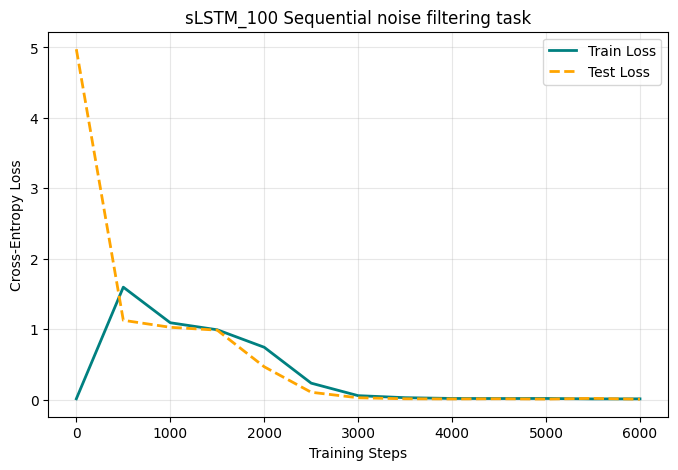

STEP: 6000 | TRAIN LOSS: 0.0094 | TEST LOSS: 0.0040


  0%|          | 0/10 [00:00<?, ?it/s]

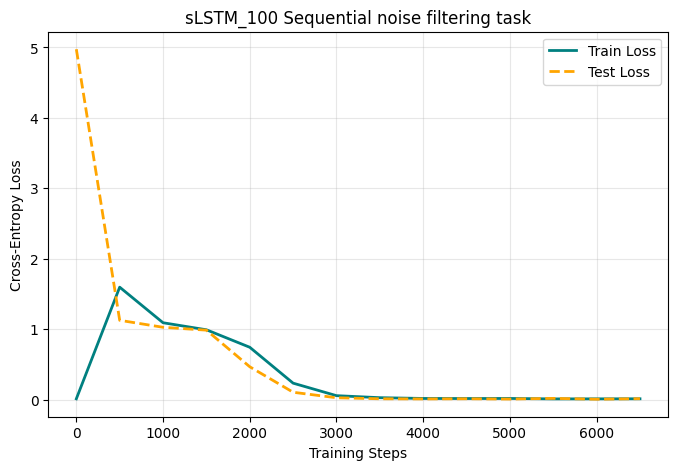

STEP: 6500 | TRAIN LOSS: 0.0102 | TEST LOSS: 0.0115


  0%|          | 0/10 [00:00<?, ?it/s]

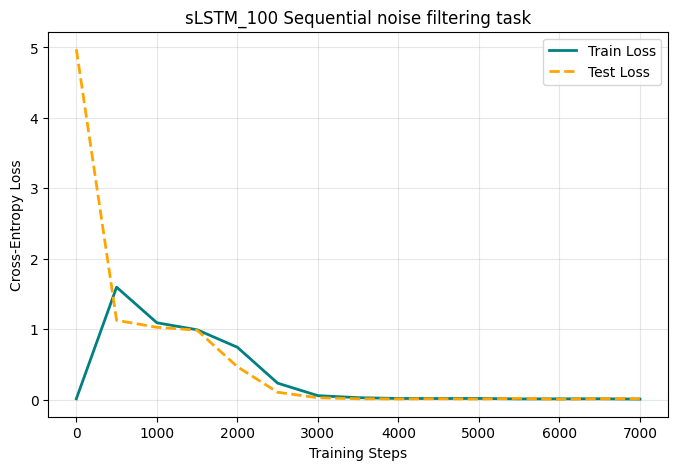

STEP: 7000 | TRAIN LOSS: 0.0060 | TEST LOSS: 0.0102


In [ ]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(sLSTM_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_sLSTM, 
                 test_break=500, 
                 model_name="sLSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

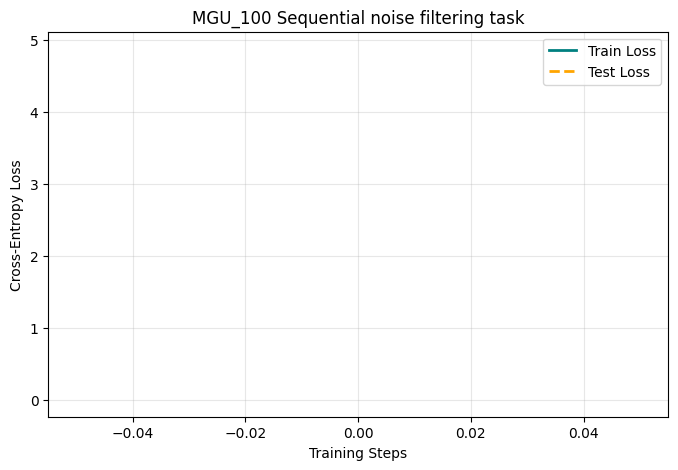

STEP: 0 | TRAIN LOSS: 0.0099 | TEST LOSS: 4.8735


  0%|          | 0/10 [00:00<?, ?it/s]

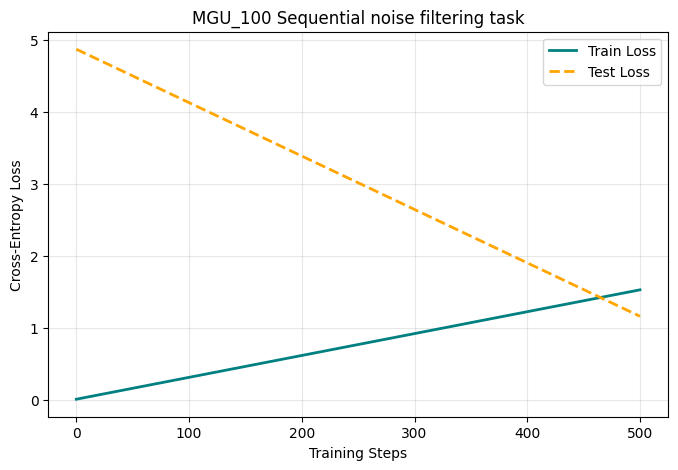

STEP: 500 | TRAIN LOSS: 1.5300 | TEST LOSS: 1.1625


  0%|          | 0/10 [00:00<?, ?it/s]

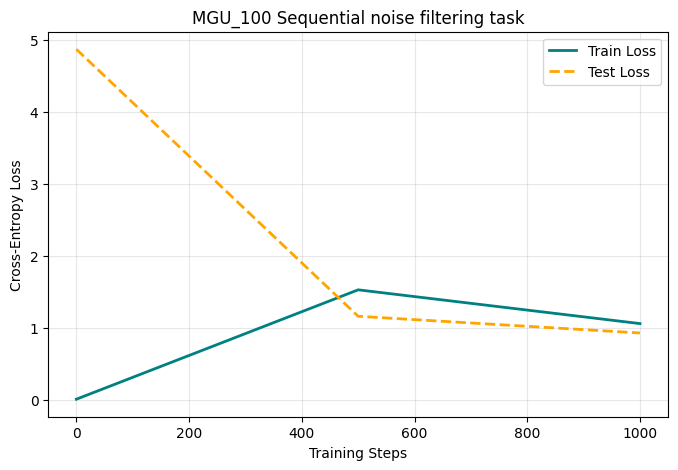

STEP: 1000 | TRAIN LOSS: 1.0610 | TEST LOSS: 0.9304


  0%|          | 0/10 [00:00<?, ?it/s]

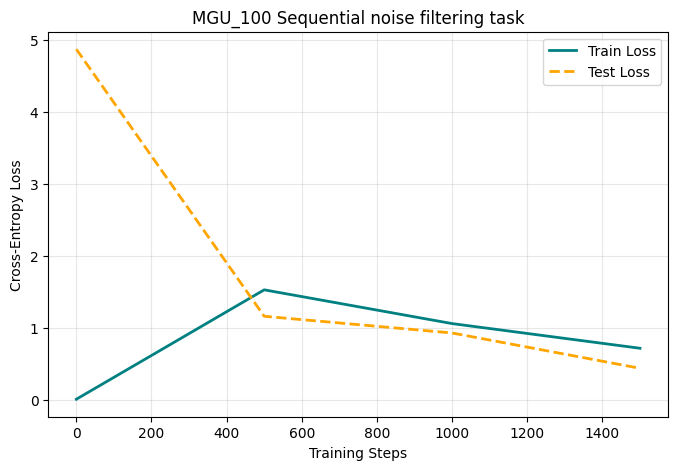

STEP: 1500 | TRAIN LOSS: 0.7181 | TEST LOSS: 0.4398


  0%|          | 0/10 [00:00<?, ?it/s]

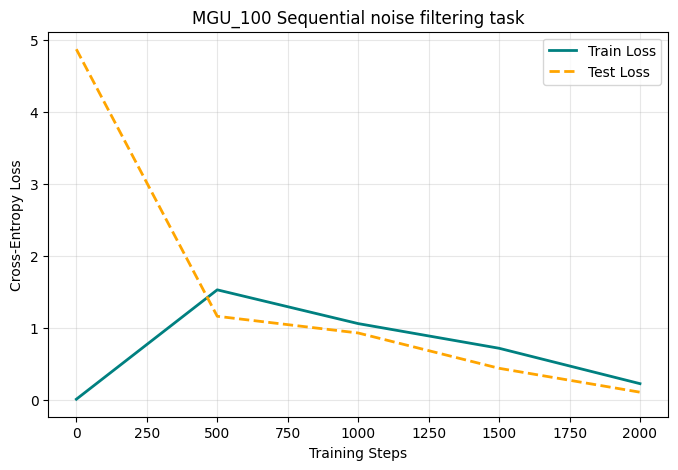

STEP: 2000 | TRAIN LOSS: 0.2262 | TEST LOSS: 0.1075


  0%|          | 0/10 [00:00<?, ?it/s]

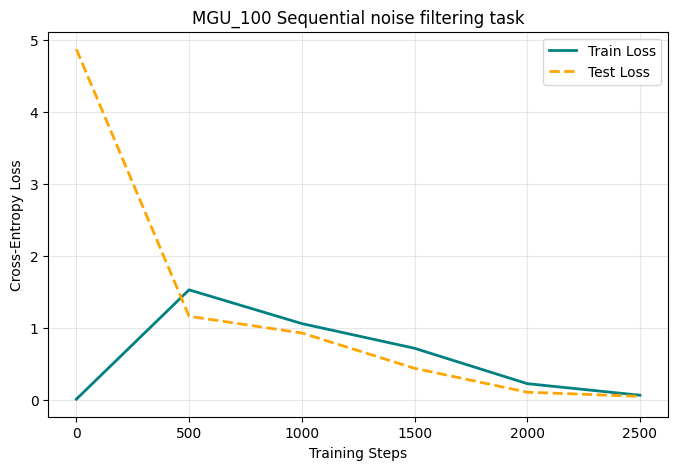

STEP: 2500 | TRAIN LOSS: 0.0653 | TEST LOSS: 0.0497


  0%|          | 0/10 [00:00<?, ?it/s]

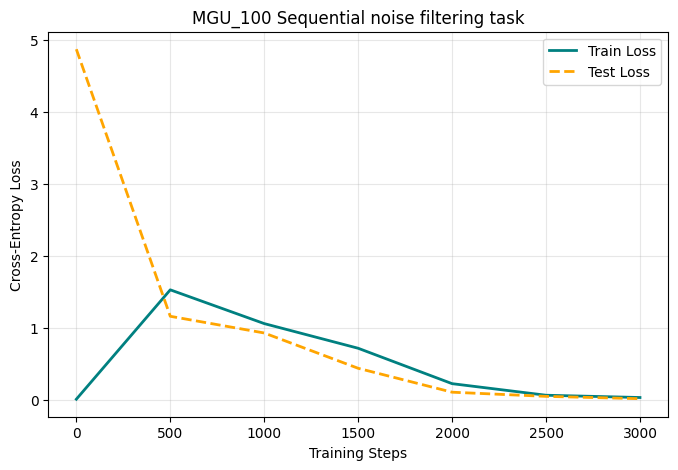

STEP: 3000 | TRAIN LOSS: 0.0337 | TEST LOSS: 0.0173


  0%|          | 0/10 [00:00<?, ?it/s]

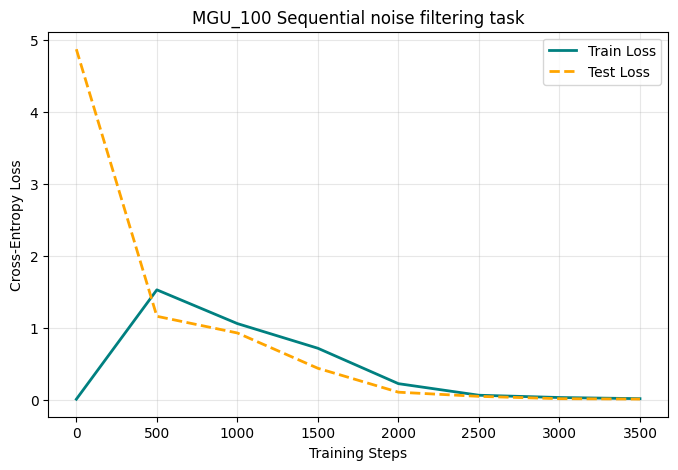

STEP: 3500 | TRAIN LOSS: 0.0177 | TEST LOSS: 0.0119


  0%|          | 0/10 [00:00<?, ?it/s]

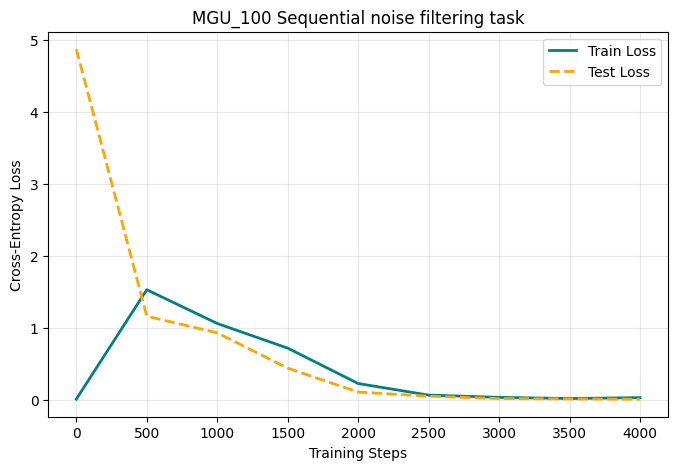

STEP: 4000 | TRAIN LOSS: 0.0300 | TEST LOSS: 0.0079


  0%|          | 0/10 [00:00<?, ?it/s]

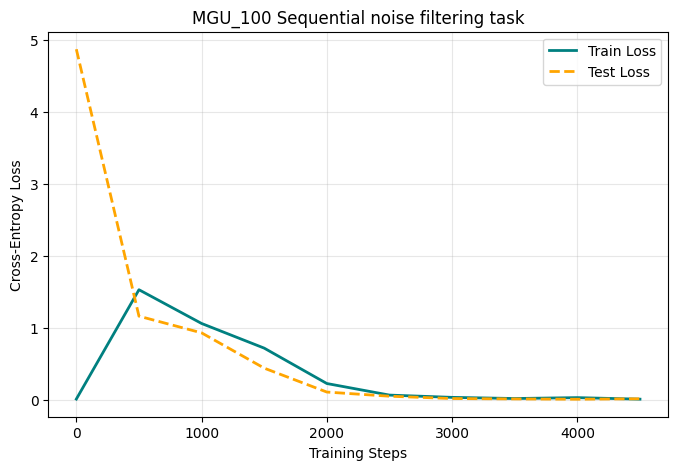

STEP: 4500 | TRAIN LOSS: 0.0086 | TEST LOSS: 0.0140


  0%|          | 0/10 [00:00<?, ?it/s]

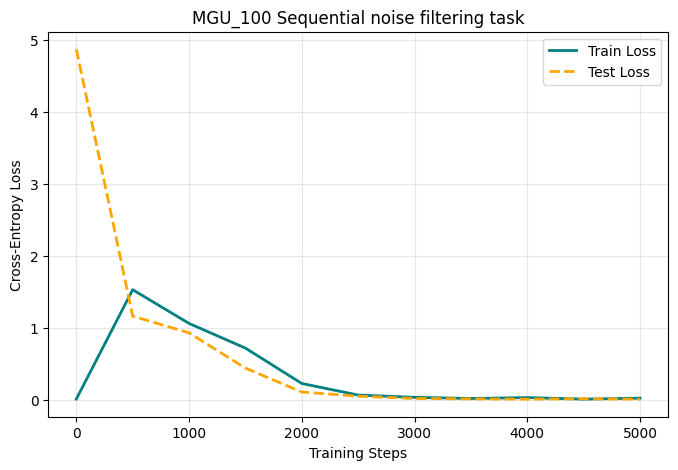

STEP: 5000 | TRAIN LOSS: 0.0225 | TEST LOSS: 0.0075


  0%|          | 0/10 [00:00<?, ?it/s]

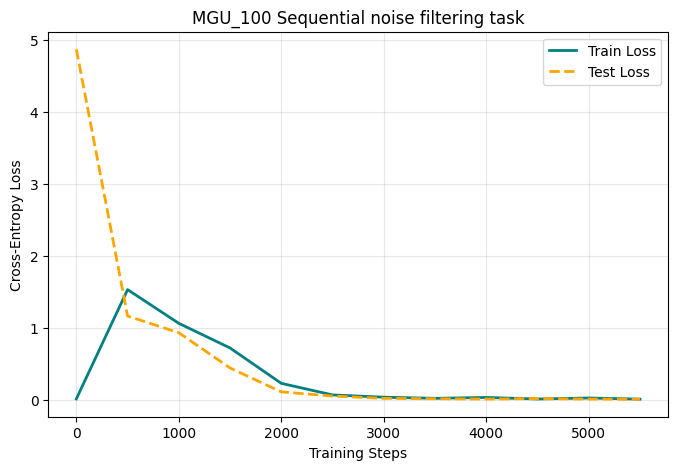

STEP: 5500 | TRAIN LOSS: 0.0064 | TEST LOSS: 0.0054


  0%|          | 0/10 [00:00<?, ?it/s]

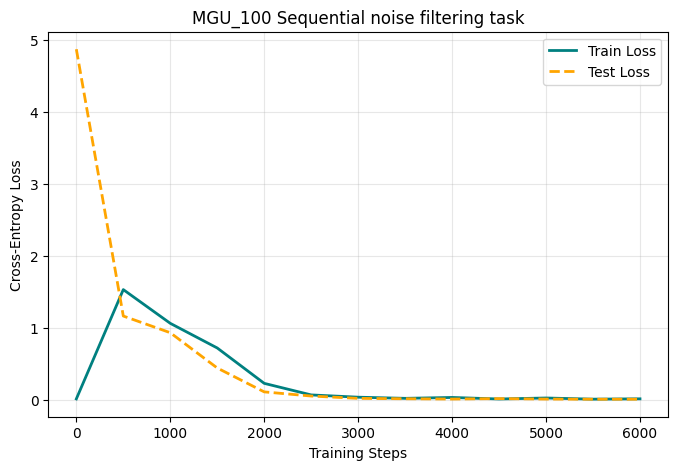

STEP: 6000 | TRAIN LOSS: 0.0111 | TEST LOSS: 0.0056


  0%|          | 0/10 [00:00<?, ?it/s]

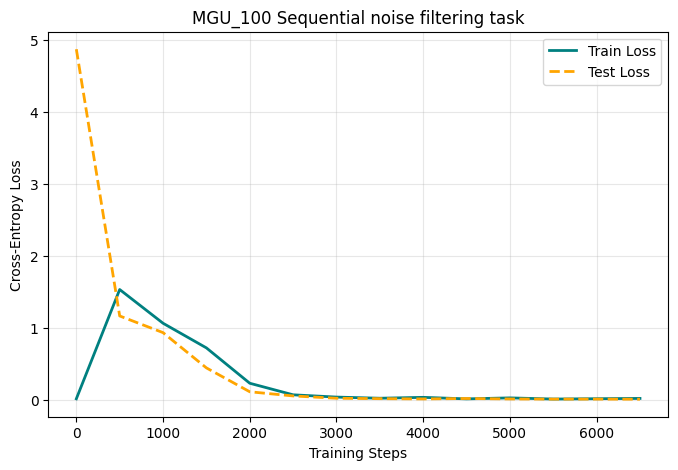

STEP: 6500 | TRAIN LOSS: 0.0150 | TEST LOSS: 0.0039


  0%|          | 0/10 [00:00<?, ?it/s]

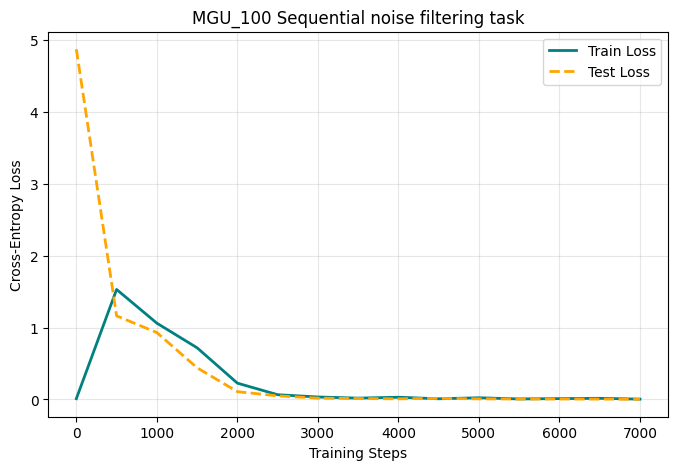

STEP: 7000 | TRAIN LOSS: 0.0038 | TEST LOSS: 0.0024


In [7]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(MGU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_MGU, 
                 test_break=500, 
                 model_name="MGU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

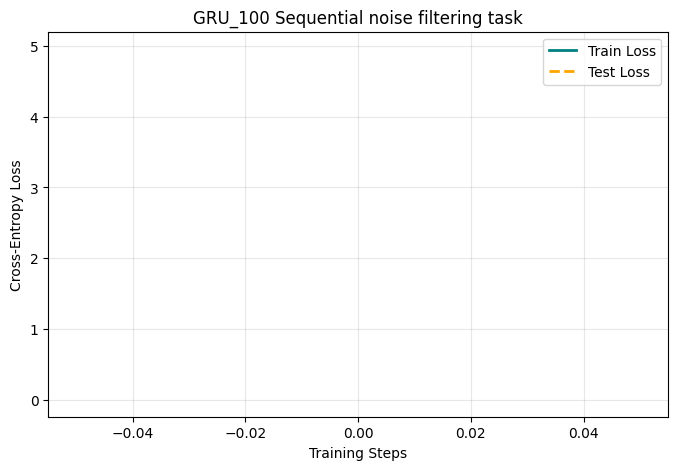

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9527


  0%|          | 0/10 [00:00<?, ?it/s]

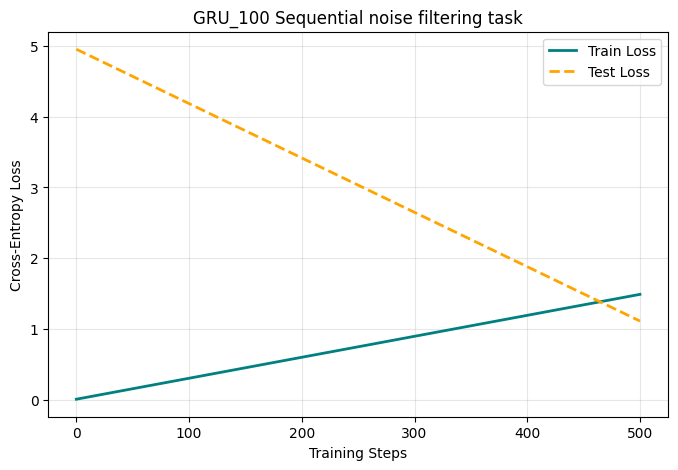

STEP: 500 | TRAIN LOSS: 1.4909 | TEST LOSS: 1.1136


  0%|          | 0/10 [00:00<?, ?it/s]

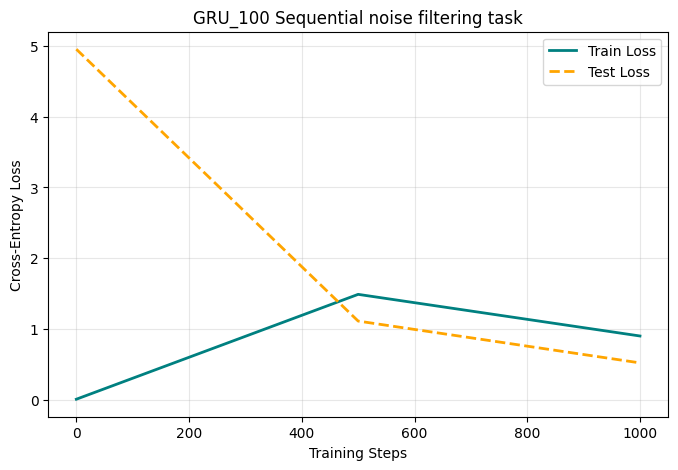

STEP: 1000 | TRAIN LOSS: 0.9028 | TEST LOSS: 0.5231


  0%|          | 0/10 [00:00<?, ?it/s]

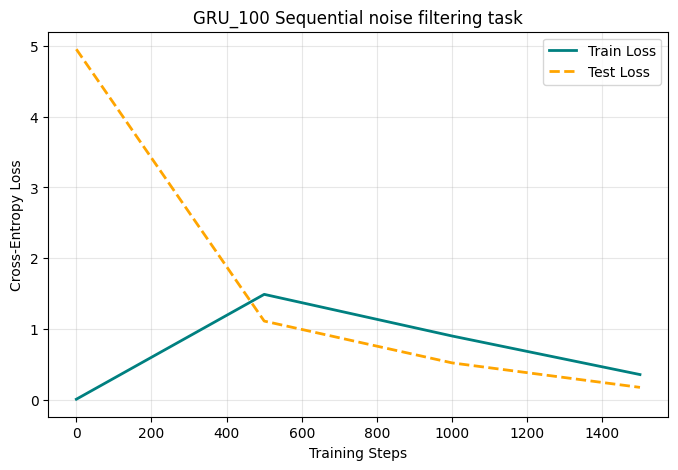

STEP: 1500 | TRAIN LOSS: 0.3583 | TEST LOSS: 0.1771


  0%|          | 0/10 [00:00<?, ?it/s]

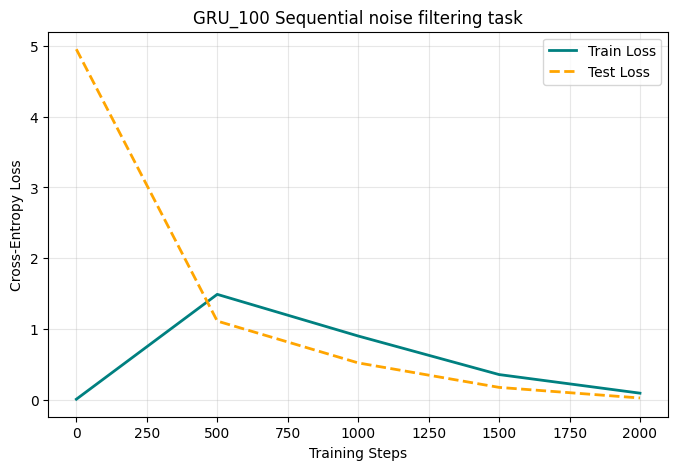

STEP: 2000 | TRAIN LOSS: 0.0954 | TEST LOSS: 0.0273


  0%|          | 0/10 [00:00<?, ?it/s]

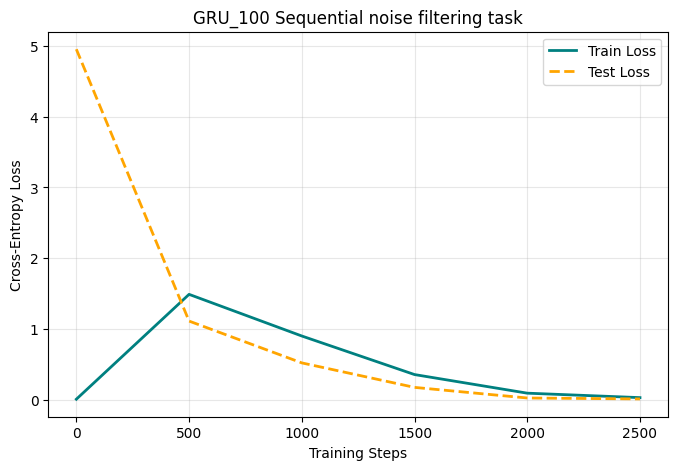

STEP: 2500 | TRAIN LOSS: 0.0325 | TEST LOSS: 0.0140


  0%|          | 0/10 [00:00<?, ?it/s]

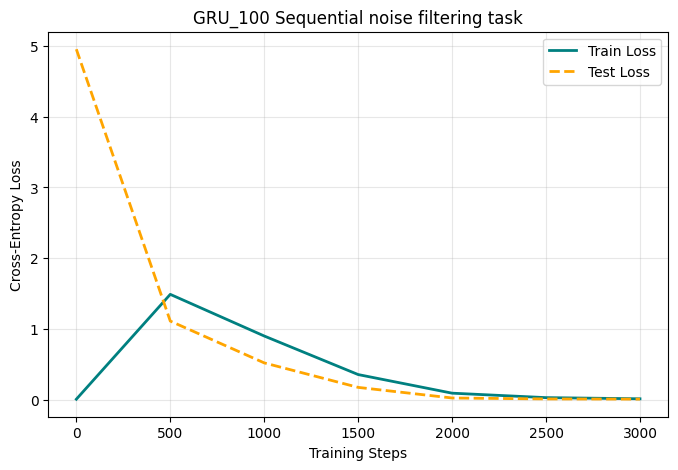

STEP: 3000 | TRAIN LOSS: 0.0161 | TEST LOSS: 0.0114


  0%|          | 0/10 [00:00<?, ?it/s]

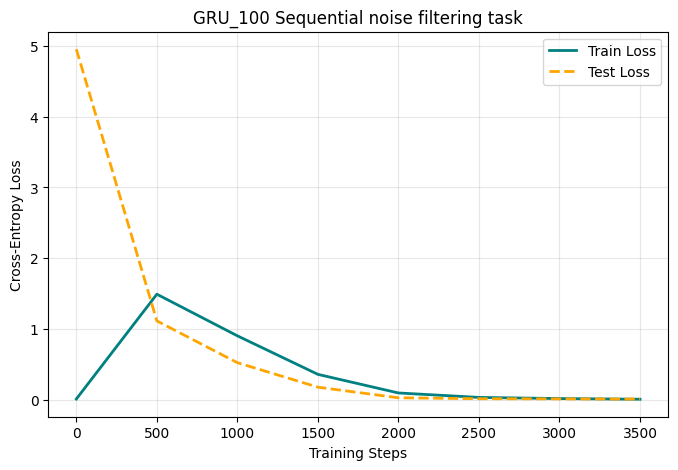

STEP: 3500 | TRAIN LOSS: 0.0070 | TEST LOSS: 0.0089


  0%|          | 0/10 [00:00<?, ?it/s]

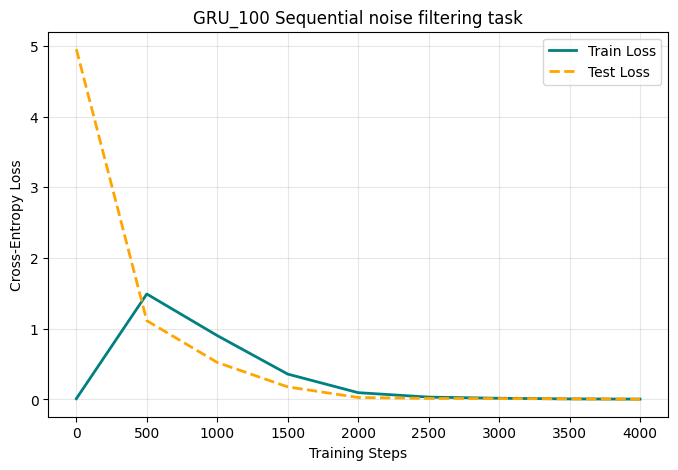

STEP: 4000 | TRAIN LOSS: 0.0043 | TEST LOSS: 0.0026


  0%|          | 0/10 [00:00<?, ?it/s]

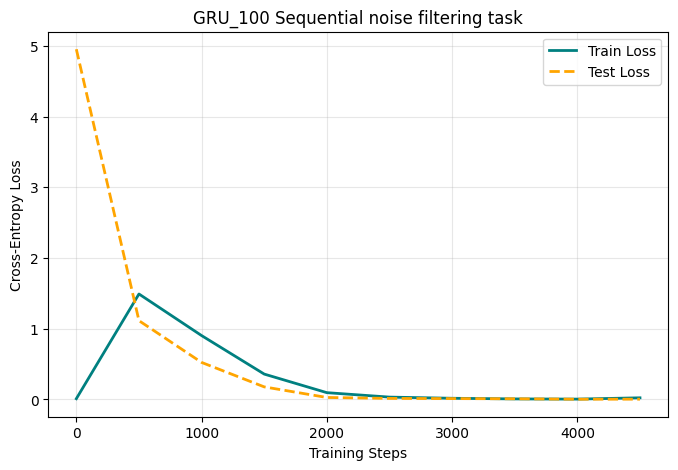

STEP: 4500 | TRAIN LOSS: 0.0225 | TEST LOSS: 0.0033


  0%|          | 0/10 [00:00<?, ?it/s]

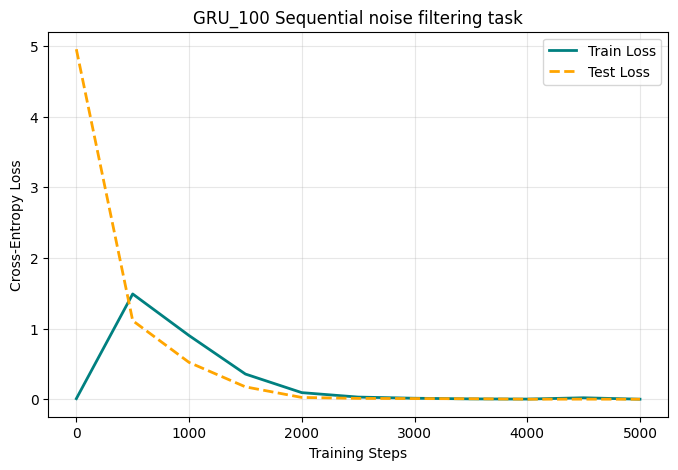

STEP: 5000 | TRAIN LOSS: 0.0026 | TEST LOSS: 0.0022


  0%|          | 0/10 [00:00<?, ?it/s]

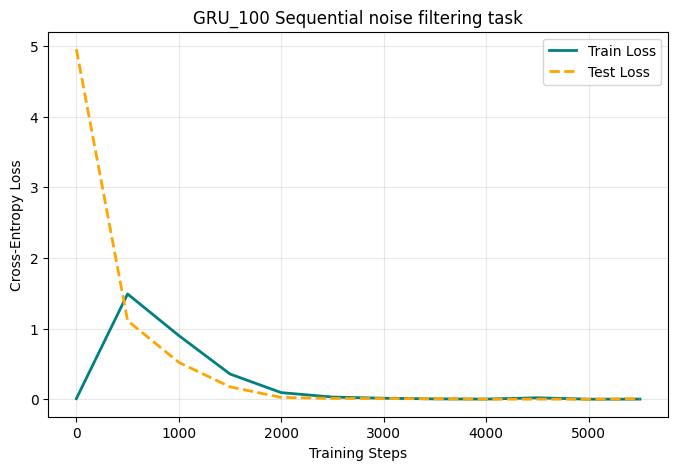

STEP: 5500 | TRAIN LOSS: 0.0038 | TEST LOSS: 0.0090


  0%|          | 0/10 [00:00<?, ?it/s]

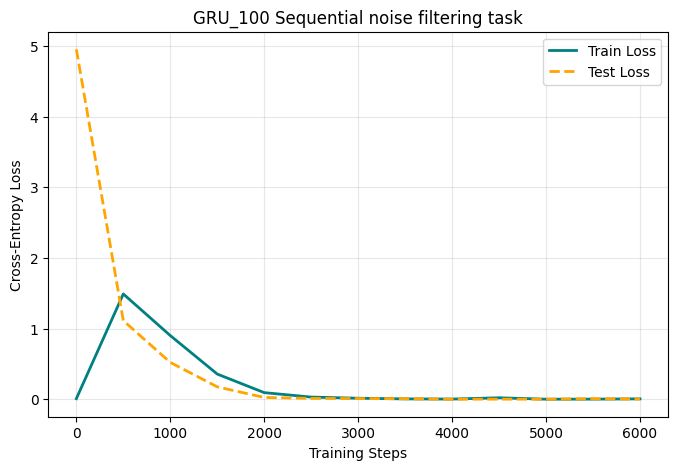

STEP: 6000 | TRAIN LOSS: 0.0073 | TEST LOSS: 0.0046


  0%|          | 0/10 [00:00<?, ?it/s]

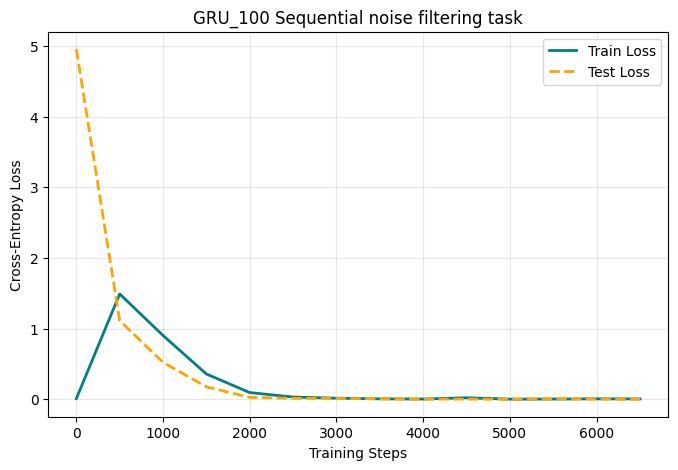

STEP: 6500 | TRAIN LOSS: 0.0058 | TEST LOSS: 0.0016


  0%|          | 0/10 [00:00<?, ?it/s]

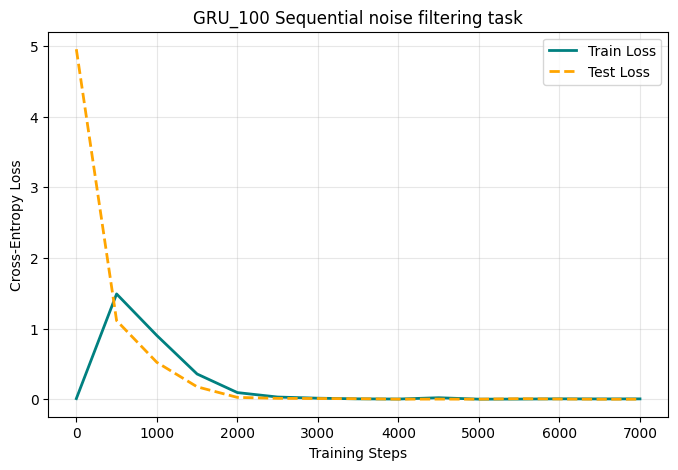

STEP: 7000 | TRAIN LOSS: 0.0066 | TEST LOSS: 0.0021


In [8]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(GRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_GRU, 
                 test_break=500, 
                 model_name="GRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

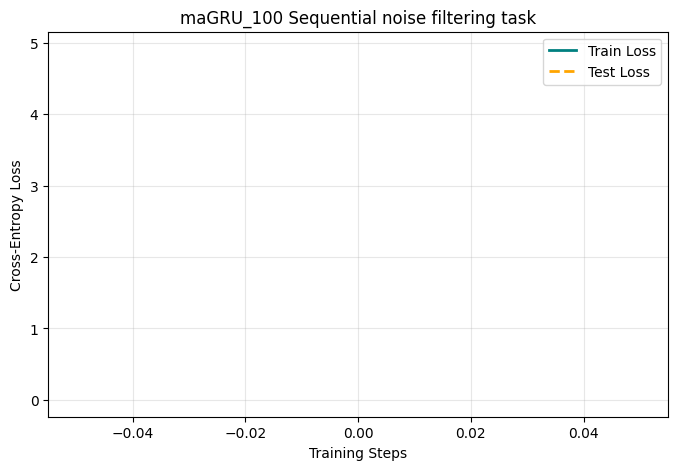

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9074


  0%|          | 0/10 [00:00<?, ?it/s]

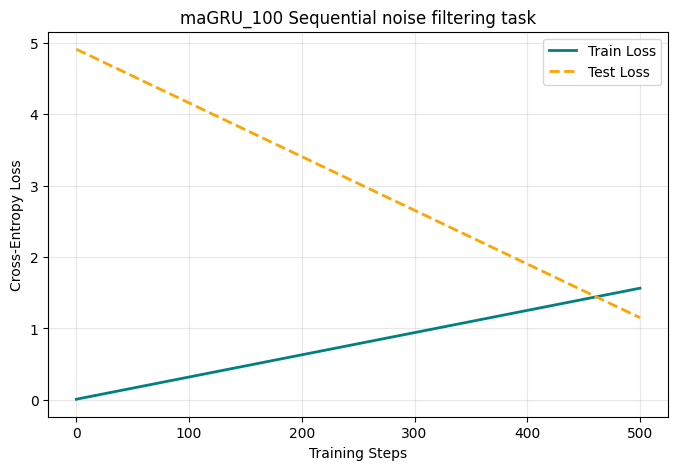

STEP: 500 | TRAIN LOSS: 1.5635 | TEST LOSS: 1.1511


  0%|          | 0/10 [00:00<?, ?it/s]

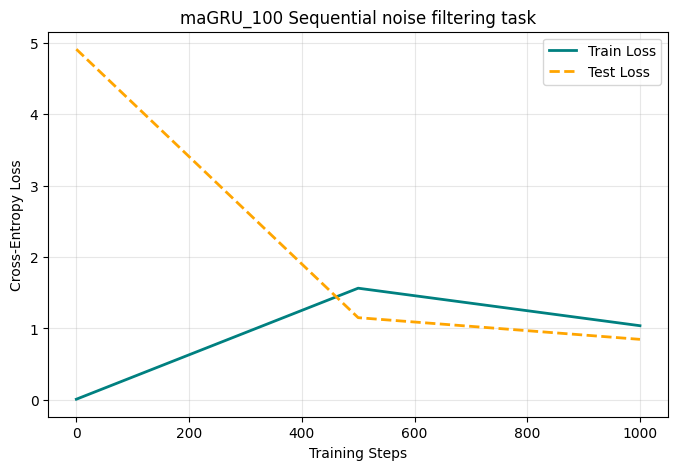

STEP: 1000 | TRAIN LOSS: 1.0386 | TEST LOSS: 0.8477


  0%|          | 0/10 [00:00<?, ?it/s]

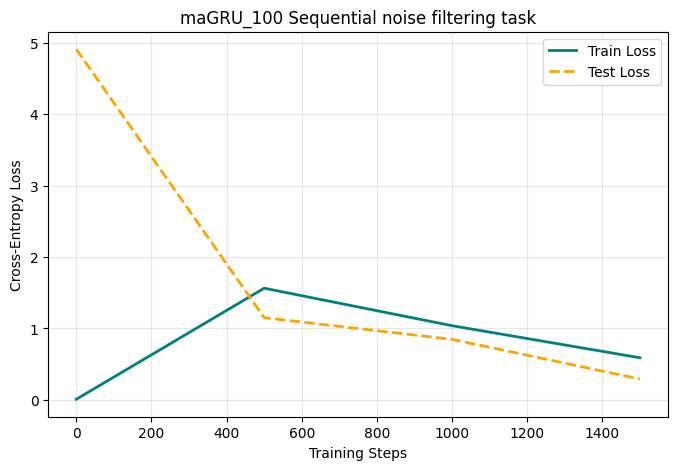

STEP: 1500 | TRAIN LOSS: 0.5900 | TEST LOSS: 0.2922


  0%|          | 0/10 [00:00<?, ?it/s]

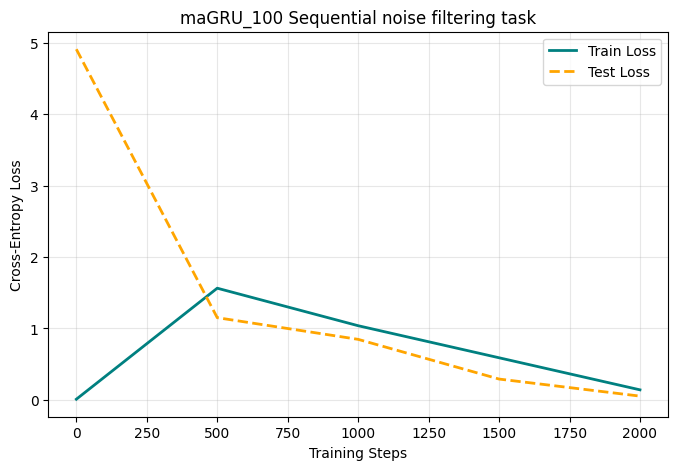

STEP: 2000 | TRAIN LOSS: 0.1413 | TEST LOSS: 0.0534


  0%|          | 0/10 [00:00<?, ?it/s]

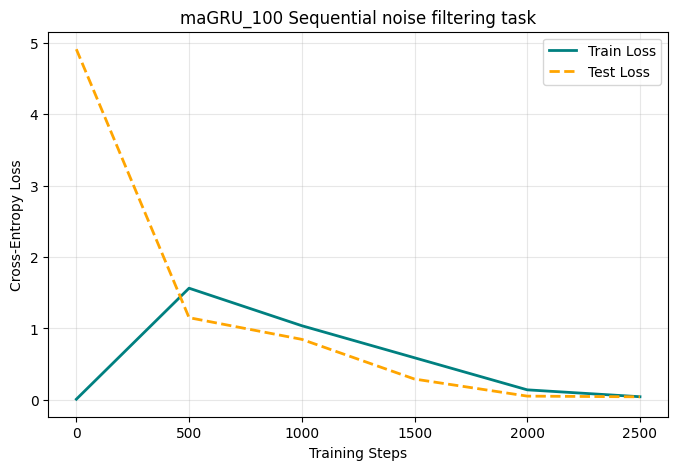

STEP: 2500 | TRAIN LOSS: 0.0449 | TEST LOSS: 0.0434


  0%|          | 0/10 [00:00<?, ?it/s]

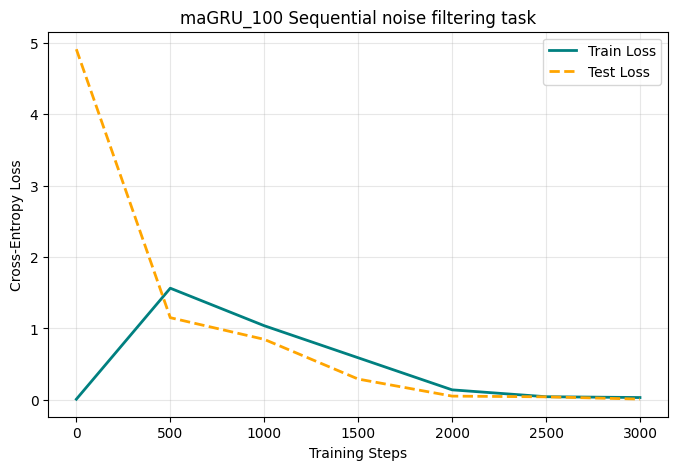

STEP: 3000 | TRAIN LOSS: 0.0336 | TEST LOSS: 0.0119


  0%|          | 0/10 [00:00<?, ?it/s]

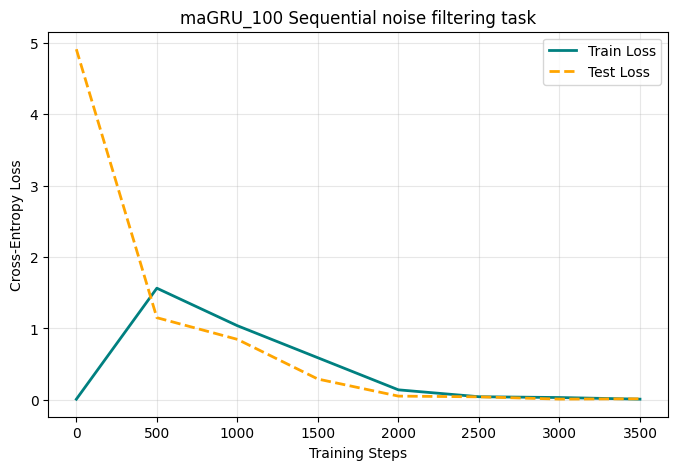

STEP: 3500 | TRAIN LOSS: 0.0108 | TEST LOSS: 0.0158


  0%|          | 0/10 [00:00<?, ?it/s]

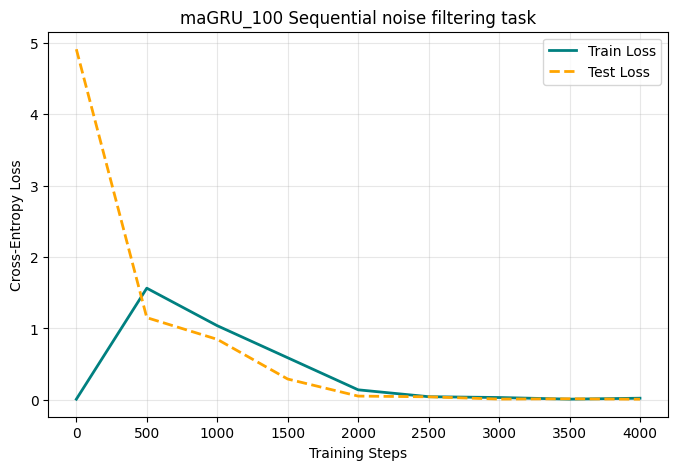

STEP: 4000 | TRAIN LOSS: 0.0238 | TEST LOSS: 0.0097


  0%|          | 0/10 [00:00<?, ?it/s]

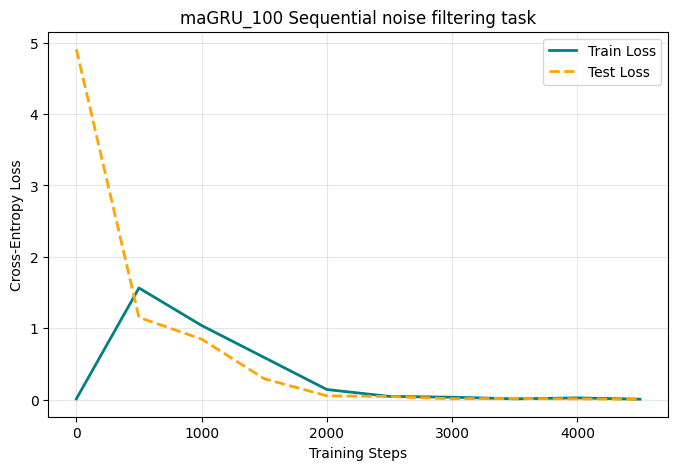

STEP: 4500 | TRAIN LOSS: 0.0062 | TEST LOSS: 0.0055


  0%|          | 0/10 [00:00<?, ?it/s]

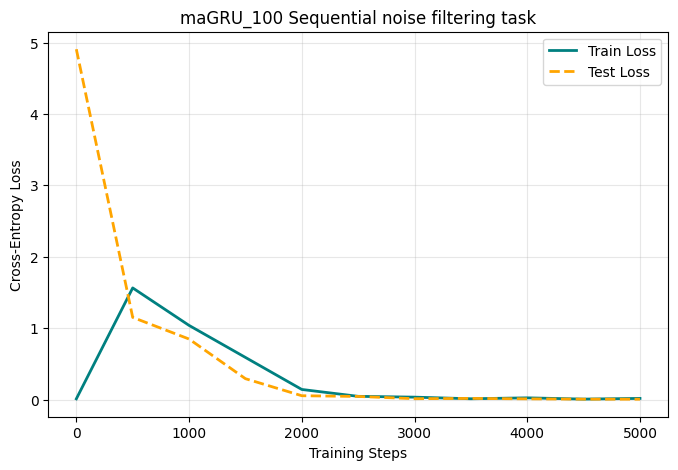

STEP: 5000 | TRAIN LOSS: 0.0159 | TEST LOSS: 0.0045


  0%|          | 0/10 [00:00<?, ?it/s]

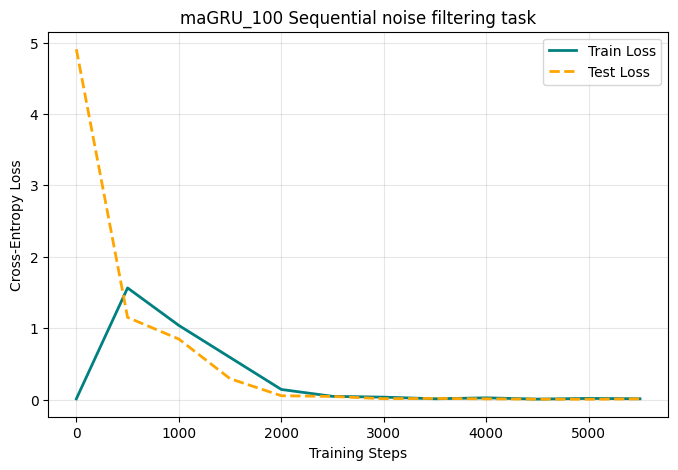

STEP: 5500 | TRAIN LOSS: 0.0109 | TEST LOSS: 0.0093


  0%|          | 0/10 [00:00<?, ?it/s]

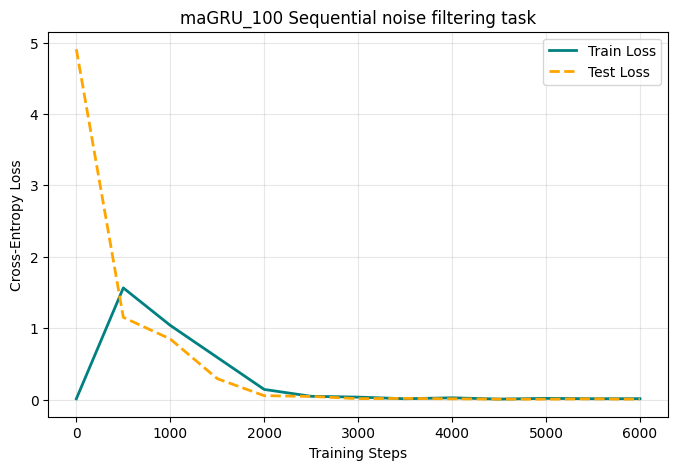

STEP: 6000 | TRAIN LOSS: 0.0117 | TEST LOSS: 0.0041


  0%|          | 0/10 [00:00<?, ?it/s]

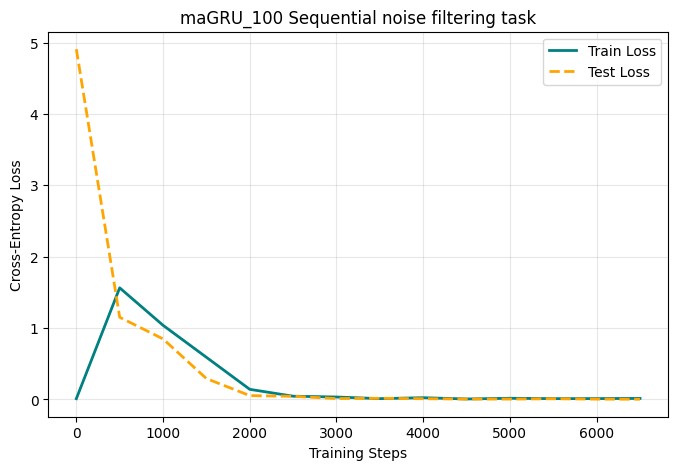

STEP: 6500 | TRAIN LOSS: 0.0140 | TEST LOSS: 0.0027


  0%|          | 0/10 [00:00<?, ?it/s]

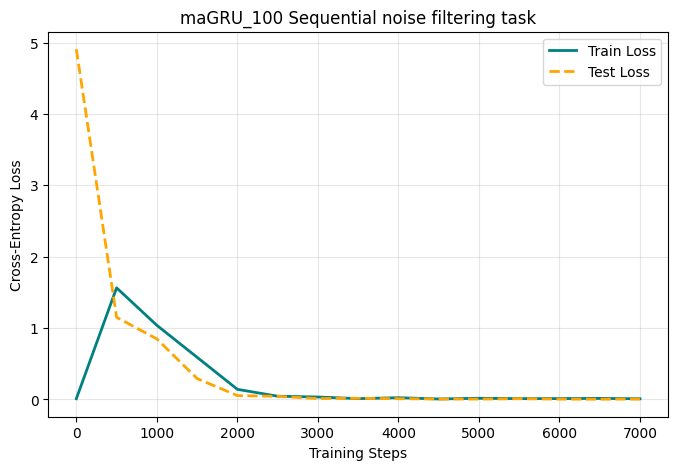

STEP: 7000 | TRAIN LOSS: 0.0094 | TEST LOSS: 0.0051


In [9]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(maGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_maGRU, 
                 test_break=500, 
                 model_name="maGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

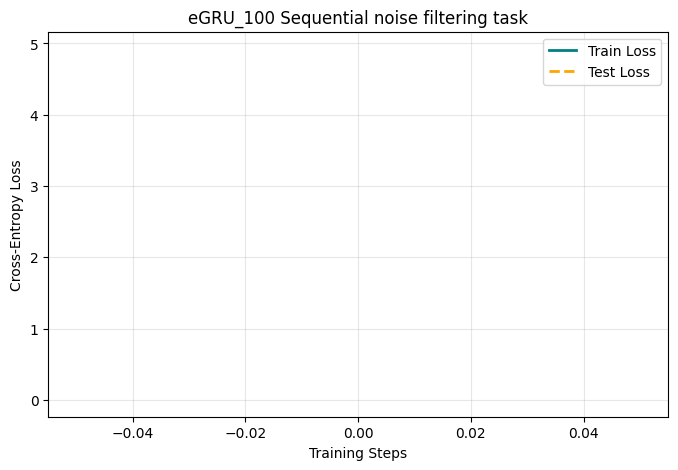

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9190


  0%|          | 0/10 [00:00<?, ?it/s]

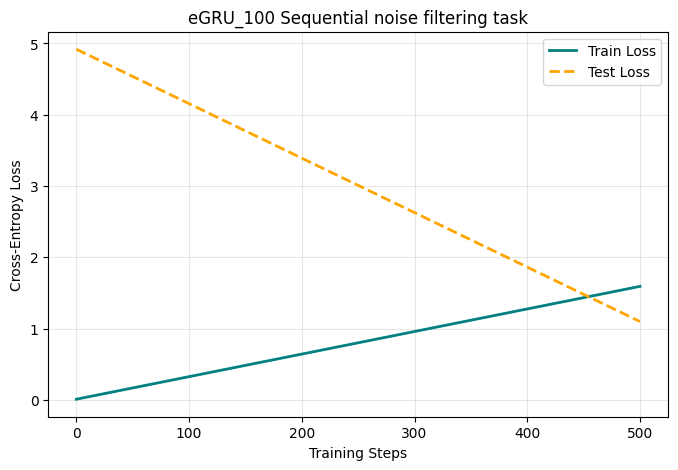

STEP: 500 | TRAIN LOSS: 1.5928 | TEST LOSS: 1.0994


  0%|          | 0/10 [00:00<?, ?it/s]

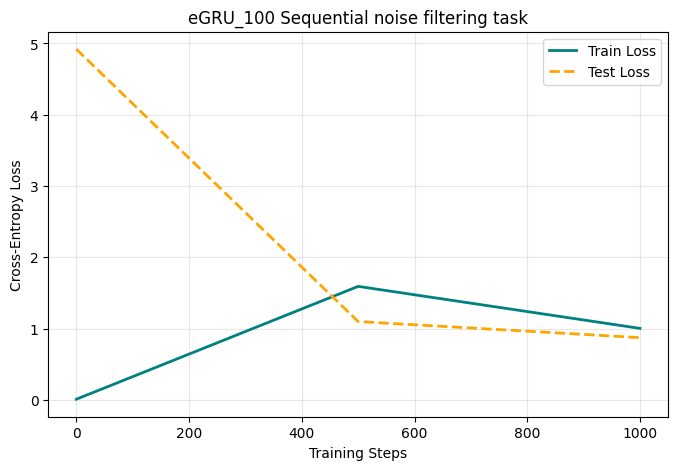

STEP: 1000 | TRAIN LOSS: 1.0036 | TEST LOSS: 0.8738


  0%|          | 0/10 [00:00<?, ?it/s]

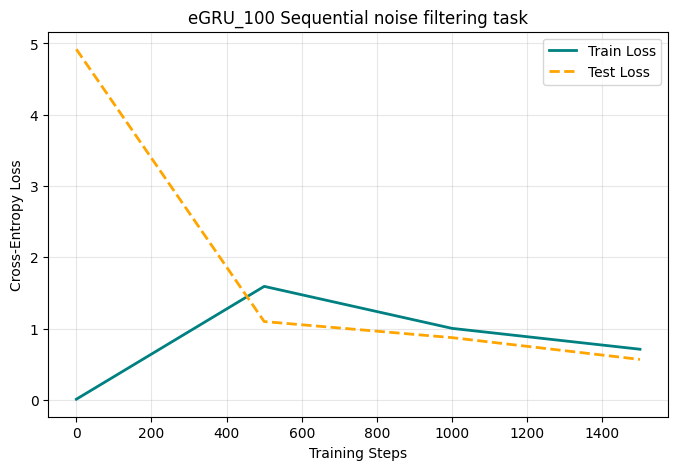

STEP: 1500 | TRAIN LOSS: 0.7110 | TEST LOSS: 0.5681


  0%|          | 0/10 [00:00<?, ?it/s]

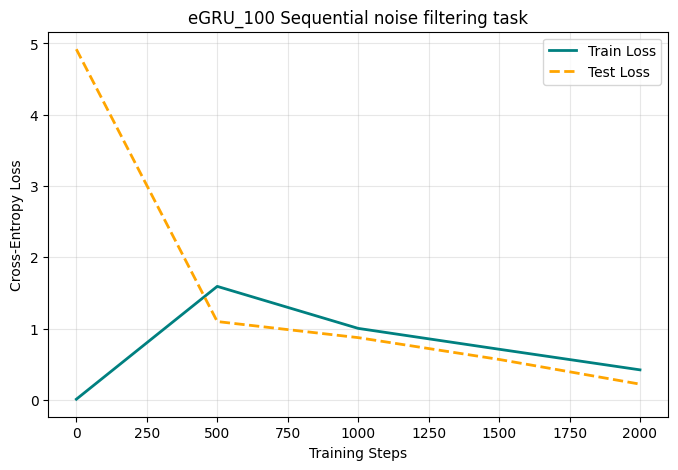

STEP: 2000 | TRAIN LOSS: 0.4219 | TEST LOSS: 0.2215


  0%|          | 0/10 [00:00<?, ?it/s]

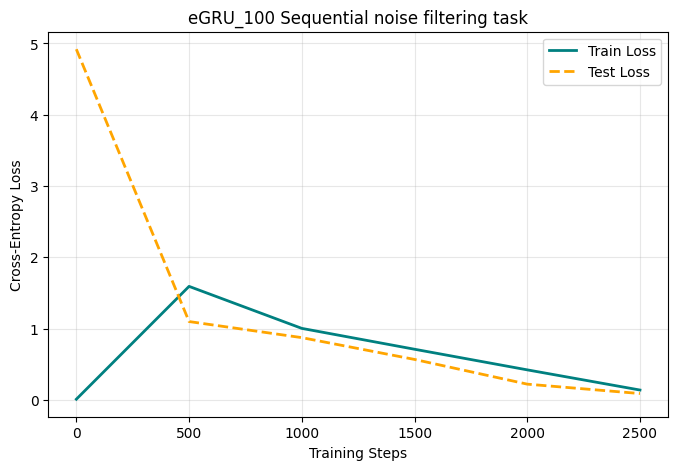

STEP: 2500 | TRAIN LOSS: 0.1388 | TEST LOSS: 0.0896


  0%|          | 0/10 [00:00<?, ?it/s]

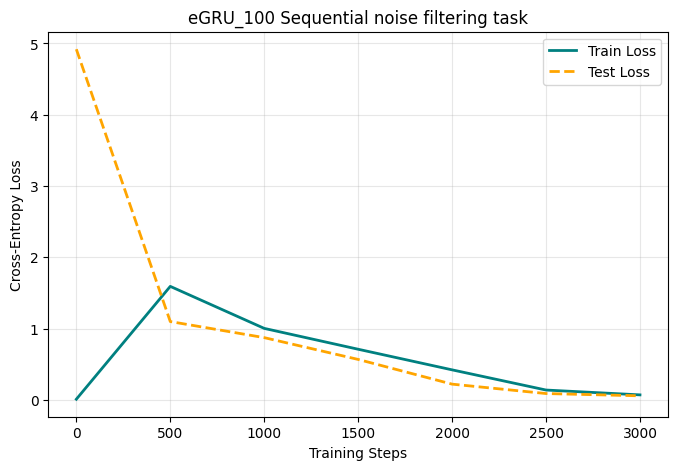

STEP: 3000 | TRAIN LOSS: 0.0710 | TEST LOSS: 0.0578


  0%|          | 0/10 [00:00<?, ?it/s]

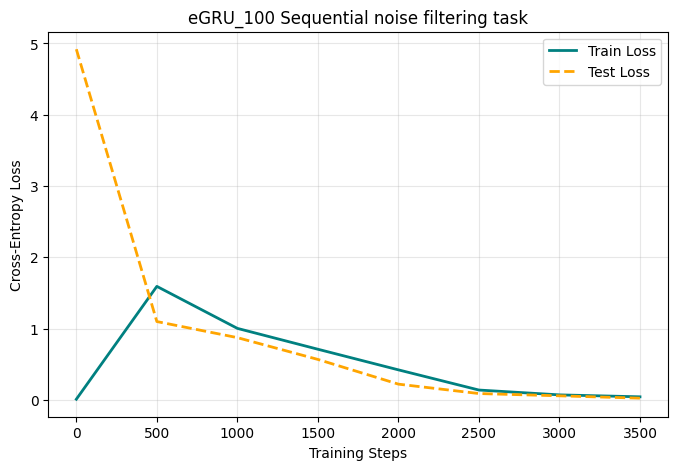

STEP: 3500 | TRAIN LOSS: 0.0437 | TEST LOSS: 0.0247


  0%|          | 0/10 [00:00<?, ?it/s]

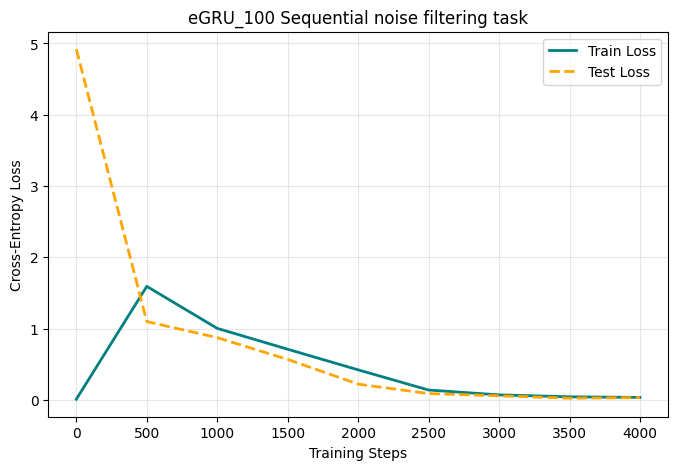

STEP: 4000 | TRAIN LOSS: 0.0352 | TEST LOSS: 0.0332


  0%|          | 0/10 [00:00<?, ?it/s]

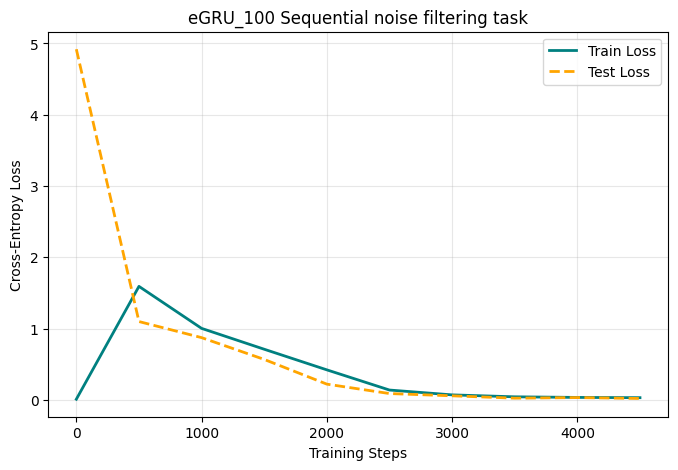

STEP: 4500 | TRAIN LOSS: 0.0317 | TEST LOSS: 0.0205


  0%|          | 0/10 [00:00<?, ?it/s]

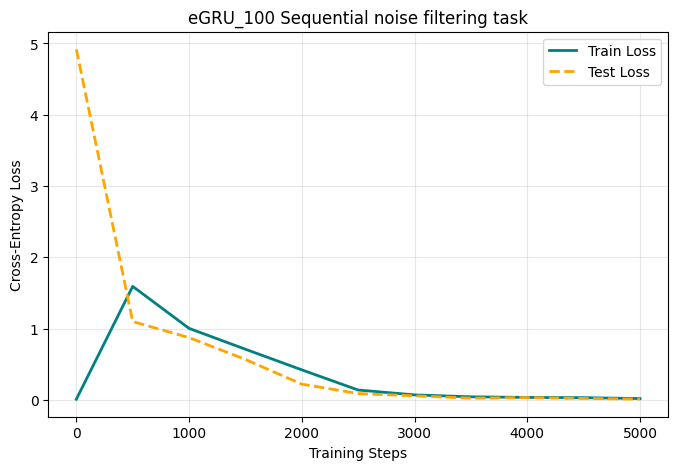

STEP: 5000 | TRAIN LOSS: 0.0190 | TEST LOSS: 0.0112


  0%|          | 0/10 [00:00<?, ?it/s]

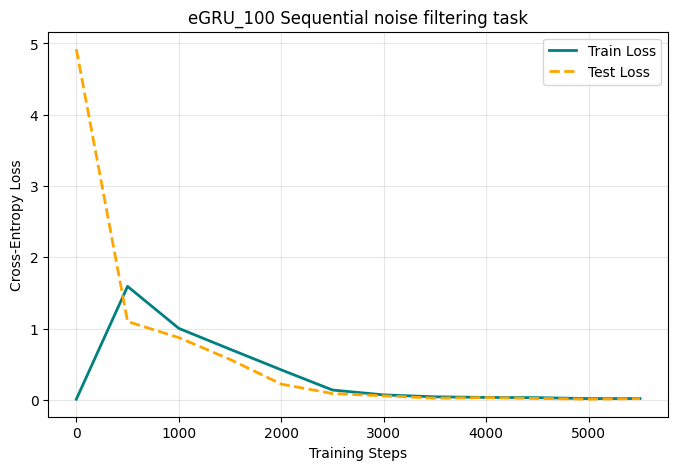

STEP: 5500 | TRAIN LOSS: 0.0198 | TEST LOSS: 0.0176


  0%|          | 0/10 [00:00<?, ?it/s]

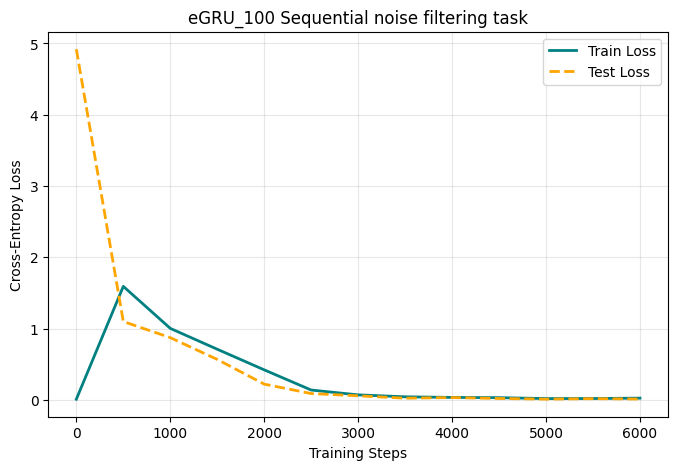

STEP: 6000 | TRAIN LOSS: 0.0252 | TEST LOSS: 0.0124


  0%|          | 0/10 [00:00<?, ?it/s]

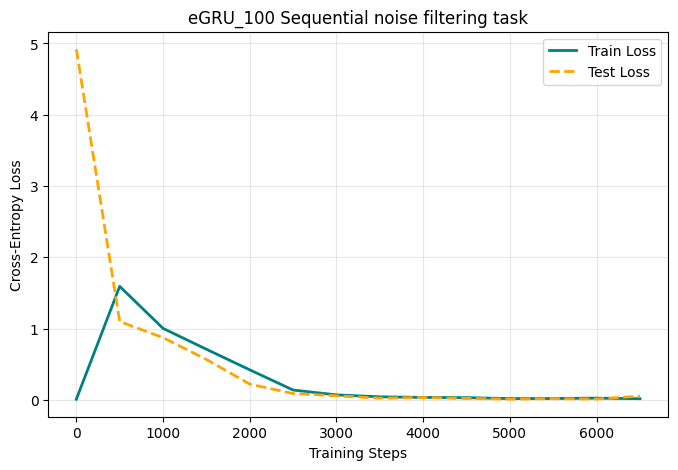

STEP: 6500 | TRAIN LOSS: 0.0170 | TEST LOSS: 0.0539


  0%|          | 0/10 [00:00<?, ?it/s]

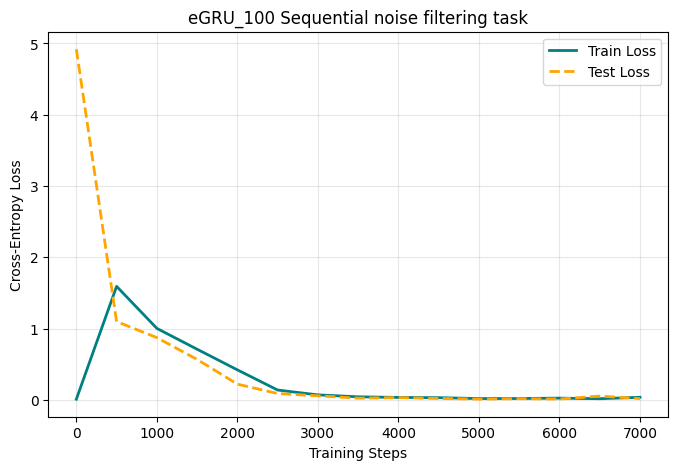

STEP: 7000 | TRAIN LOSS: 0.0371 | TEST LOSS: 0.0191


In [10]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(eGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_eGRU, 
                 test_break=500, 
                 model_name="eGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

## Testing the models!

In [5]:
def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [6]:
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

In [7]:


load_model("./models/ex2/mLSTM_100_ex2_epoch_7000.pt", "cuda", mLSTM_model, opt_mLSTM)
load_model("./models/ex2/mLSTMLite_100_ex2_epoch_7000.pt", "cuda", mLSTMLite_model, opt_mLSTMLite)
load_model("./models/ex2/sLSTM_100_ex2_epoch_7000.pt", "cuda", sLSTM_model, opt_sLSTM)
load_model("./models/ex2/MGU_100_ex2_epoch_7000.pt", "cuda", MGU_model, opt_MGU)
load_model("./models/ex2/maGRU_100_ex2_epoch_7000.pt", "cuda", maGRU_model, opt_maGRU)
load_model("./models/ex2/GRU_100_ex2_epoch_7000.pt", "cuda", GRU_model, opt_GRU)
load_model("./models/ex2/eGRU_100_ex2_epoch_7000.pt", "cuda", eGRU_model, opt_eGRU)

7001

In [9]:

ex1_mlstm_50   =  evaluate_ex2(mLSTM_model, copy_size=10, buffer_size=15,   total_batches=test_batches, batch_size=batch_size, vocab=vocab, teacher_forcing=False)
ex1_mlstm_100  =  evaluate_ex2(mLSTM_model, copy_size=10, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab,  teacher_forcing=False)
ex1_mlstm_250  =  evaluate_ex2(mLSTM_model, copy_size=10, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab,  teacher_forcing=False)
ex1_mlstm_500  =  evaluate_ex2(mLSTM_model, copy_size=10, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab,  teacher_forcing=False)
ex1_mlstm_750  =  evaluate_ex2(mLSTM_model, copy_size=10, buffer_size=100,  total_batches=test_batches, batch_size=batch_size, vocab=vocab, teacher_forcing=False)
ex1_mlstm_1000 = evaluate_ex2(mLSTM_model,  copy_size=10,  buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab, teacher_forcing=False)

print("mLSTM bracket closing difference at buffer_size=50: ",   ex1_mlstm_50)
print("mLSTM bracket closing difference at buffer_size=100: ",  ex1_mlstm_100)
print("mLSTM bracket closing difference at buffer_size=250: ",  ex1_mlstm_250)
print("mLSTM bracket closing difference at buffer_size=500: ",  ex1_mlstm_500)
print("mLSTM bracket closing difference at buffer_size=750: ",  ex1_mlstm_750)
print("mLSTM bracket closing difference at buffer_size=1000: ", ex1_mlstm_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTM bracket closing difference at buffer_size=50:  0.5889851610259255
mLSTM bracket closing difference at buffer_size=100:  0.5836633797919396
mLSTM bracket closing difference at buffer_size=250:  0.588644815553533
mLSTM bracket closing difference at buffer_size=500:  0.5914294690188795
mLSTM bracket closing difference at buffer_size=750:  0.587654715127284
mLSTM bracket closing difference at buffer_size=1000:  0.5965037251463031


In [10]:

ex1_mlstmlite_50   = evaluate_ex2(mLSTMLite_model, copy_size=10, buffer_size=15,  total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mlstmlite_100  = evaluate_ex2(mLSTMLite_model, copy_size=10, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mlstmlite_250  = evaluate_ex2(mLSTMLite_model, copy_size=10, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mlstmlite_500  = evaluate_ex2(mLSTMLite_model, copy_size=10, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mlstmlite_750  = evaluate_ex2(mLSTMLite_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mlstmlite_1000 = evaluate_ex2(mLSTMLite_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)

print("mLSTMLite bracket closing difference at buffer_size=50: ",   ex1_mlstmlite_50)
print("mLSTMLite bracket closing difference at buffer_size=100: ",  ex1_mlstmlite_100)
print("mLSTMLite bracket closing difference at buffer_size=250: ",  ex1_mlstmlite_250)
print("mLSTMLite bracket closing difference at buffer_size=500: ",  ex1_mlstmlite_500)
print("mLSTMLite bracket closing difference at buffer_size=750: ",  ex1_mlstmlite_750)
print("mLSTMLite bracket closing difference at buffer_size=1000: ", ex1_mlstmlite_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTMLite bracket closing difference at buffer_size=50:  0.5663057016854239
mLSTMLite bracket closing difference at buffer_size=100:  0.5635210514658748
mLSTMLite bracket closing difference at buffer_size=250:  0.5602104055999529
mLSTMLite bracket closing difference at buffer_size=500:  0.5660272382273532
mLSTMLite bracket closing difference at buffer_size=750:  0.5641708046492964
mLSTMLite bracket closing difference at buffer_size=1000:  0.6041769934172677


In [11]:
ex1_cgru_50 =     evaluate_ex2(GRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_cgru_100 =   evaluate_ex2(GRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_cgru_250 =   evaluate_ex2(GRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_cgru_500 =   evaluate_ex2(GRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_cgru_750 =   evaluate_ex2(GRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_cgru_1000 = evaluate_ex2(GRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)

print("GRU sequential noise filtering at buffer_size=50: ", ex1_cgru_50)
print("GRU sequential noise filtering at buffer_size=100: ", ex1_cgru_100)
print("GRU sequential noise filtering at buffer_size=250: ", ex1_cgru_250)
print("GRU sequential noise filtering at buffer_size=500: ", ex1_cgru_500)
print("GRU sequential noise filtering at buffer_size=750: ", ex1_cgru_750)
print("GRU sequential noise filtering at buffer_size=1000: ", ex1_cgru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

GRU sequential noise filtering at buffer_size=50:  0.001516089138418141
GRU sequential noise filtering at buffer_size=100:  0.0004641089224173586
GRU sequential noise filtering at buffer_size=250:  0.012314356658331091
GRU sequential noise filtering at buffer_size=500:  0.16271658669603933
GRU sequential noise filtering at buffer_size=750:  0.28196164036151206
GRU sequential noise filtering at buffer_size=1000:  0.3509591643763061


In [12]:
ex1_mgu_50 =     evaluate_ex2(MGU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mgu_100 =   evaluate_ex2(MGU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mgu_250 =   evaluate_ex2(MGU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mgu_500 =   evaluate_ex2(MGU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mgu_750 =   evaluate_ex2(MGU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_mgu_1000 = evaluate_ex2(MGU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)

print("MGU sequential noise filtering at buffer_size=50: ",   ex1_mgu_50)
print("MGU sequential noise filtering at buffer_size=100: ",  ex1_mgu_100)
print("MGU sequential noise filtering at buffer_size=250: ",  ex1_mgu_250)
print("MGU sequential noise filtering at buffer_size=500: ",  ex1_mgu_500)
print("MGU sequential noise filtering at buffer_size=750: ",  ex1_mgu_750)
print("MGU sequential noise filtering at buffer_size=1000: ", ex1_mgu_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

MGU sequential noise filtering at buffer_size=50:  0.013459158653282736
MGU sequential noise filtering at buffer_size=100:  0.001732673300061338
MGU sequential noise filtering at buffer_size=250:  0.00959158431747836
MGU sequential noise filtering at buffer_size=500:  0.12663985368343864
MGU sequential noise filtering at buffer_size=750:  0.20720916145508833
MGU sequential noise filtering at buffer_size=1000:  0.29139852066441335


In [13]:
ex1_slstm_50 =     evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_slstm_100 =   evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_slstm_250 =   evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_slstm_500 =   evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_slstm_750 =   evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_slstm_1000 = evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)

print("sLSTM sequential noise filtering difference at buffer_size=50: ",   ex1_slstm_50)
print("sLSTM sequential noise filtering difference at buffer_size=100: ",  ex1_slstm_100)
print("sLSTM sequential noise filtering difference at buffer_size=250: ",  ex1_slstm_250)
print("sLSTM sequential noise filtering difference at buffer_size=500: ",  ex1_slstm_500)
print("sLSTM sequential noise filtering difference at buffer_size=750: ",  ex1_slstm_750)
print("sLSTM sequential noise filtering difference at buffer_size=1000: ", ex1_slstm_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

sLSTM sequential noise filtering difference at buffer_size=50:  0.0029084158941439474
sLSTM sequential noise filtering difference at buffer_size=100:  0.0024752475570260298
sLSTM sequential noise filtering difference at buffer_size=250:  0.02642326772277529
sLSTM sequential noise filtering difference at buffer_size=500:  0.12441213045379904
sLSTM sequential noise filtering difference at buffer_size=750:  0.21695544814119244
sLSTM sequential noise filtering difference at buffer_size=1000:  0.28456064837403816


In [14]:
ex1_magru_50 =     evaluate_ex2(maGRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_magru_100 =   evaluate_ex2(maGRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_magru_250 =   evaluate_ex2(maGRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_magru_500 =   evaluate_ex2(maGRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_magru_750 =   evaluate_ex2(maGRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_magru_1000 = evaluate_ex2(maGRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)

print("maGRU sequential noise filtering difference at buffer_size=50: ",   ex1_magru_50)
print("maGRU sequential noise filtering difference at buffer_size=100: ",  ex1_magru_100)
print("maGRU sequential noise filtering difference at buffer_size=250: ",  ex1_magru_250)
print("maGRU sequential noise filtering difference at buffer_size=500: ",  ex1_magru_500)
print("maGRU sequential noise filtering difference at buffer_size=750: ",  ex1_magru_750)
print("maGRU sequential noise filtering difference at buffer_size=1000: ", ex1_magru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

maGRU sequential noise filtering difference at buffer_size=50:  0.006590346637467789
maGRU sequential noise filtering difference at buffer_size=100:  0.0008972772410932449
maGRU sequential noise filtering difference at buffer_size=250:  0.01983292101153938
maGRU sequential noise filtering difference at buffer_size=500:  0.14050123999171918
maGRU sequential noise filtering difference at buffer_size=750:  0.24365718249637303
maGRU sequential noise filtering difference at buffer_size=1000:  0.30495050033130267


In [8]:
ex1_eGRU_50 =     evaluate_ex2(eGRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_eGRU_100 =   evaluate_ex2(eGRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_eGRU_250 =   evaluate_ex2(eGRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_eGRU_500 =   evaluate_ex2(eGRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_eGRU_750 =   evaluate_ex2(eGRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)
ex1_eGRU_1000 = evaluate_ex2(eGRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, teacher_forcing=False, vocab=vocab)

print("eGRU sequential noise filtering difference at buffer_size=50: ",   ex1_eGRU_50)
print("eGRU sequential noise filtering difference at buffer_size=100: ",  ex1_eGRU_100)
print("eGRU sequential noise filtering difference at buffer_size=250: ",  ex1_eGRU_250)
print("eGRU sequential noise filtering difference at buffer_size=500: ",  ex1_eGRU_500)
print("eGRU sequential noise filtering difference at buffer_size=750: ",  ex1_eGRU_750)
print("eGRU sequential noise filtering difference at buffer_size=1000: ", ex1_eGRU_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU sequential noise filtering difference at buffer_size=50:  0.0057240100254738096
eGRU sequential noise filtering difference at buffer_size=100:  0.007054455571411418
eGRU sequential noise filtering difference at buffer_size=250:  0.03341584216047189
eGRU sequential noise filtering difference at buffer_size=500:  0.13709777423945985
eGRU sequential noise filtering difference at buffer_size=750:  0.212654706865254
eGRU sequential noise filtering difference at buffer_size=1000:  0.2589108949840659


In [7]:

ex1_lstm_50   =  evaluate_ex2(LSTM_model, copy_size=10, buffer_size=15,   total_batches=test_batches, batch_size=batch_size, vocab=vocab, teacher_forcing=False)
ex1_lstm_100  =  evaluate_ex2(LSTM_model, copy_size=10, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab,  teacher_forcing=False)
ex1_lstm_250  =  evaluate_ex2(LSTM_model, copy_size=10, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab,  teacher_forcing=False)
ex1_lstm_500  =  evaluate_ex2(LSTM_model, copy_size=10, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab,  teacher_forcing=False)
ex1_lstm_750  =  evaluate_ex2(LSTM_model, copy_size=10, buffer_size=100,  total_batches=test_batches, batch_size=batch_size, vocab=vocab, teacher_forcing=False)
ex1_lstm_1000 =  evaluate_ex2(LSTM_model,  copy_size=10,  buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab, teacher_forcing=False)

print("LSTM bracket closing difference at buffer_size=50: ",   ex1_lstm_50)
print("LSTM bracket closing difference at buffer_size=100: ",  ex1_lstm_100)
print("LSTM bracket closing difference at buffer_size=250: ",  ex1_lstm_250)
print("LSTM bracket closing difference at buffer_size=500: ",  ex1_lstm_500)
print("LSTM bracket closing difference at buffer_size=750: ",  ex1_lstm_750)
print("LSTM bracket closing difference at buffer_size=1000: ", ex1_lstm_1000)

Testing model at  15  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

LSTM bracket closing difference at buffer_size=50:  0.9008522900668058
LSTM bracket closing difference at buffer_size=100:  0.893750011920929
LSTM bracket closing difference at buffer_size=250:  0.7602272900668058
LSTM bracket closing difference at buffer_size=500:  0.4977272857319225
LSTM bracket closing difference at buffer_size=750:  0.06761363758282228
LSTM bracket closing difference at buffer_size=1000:  0.6426136493682861


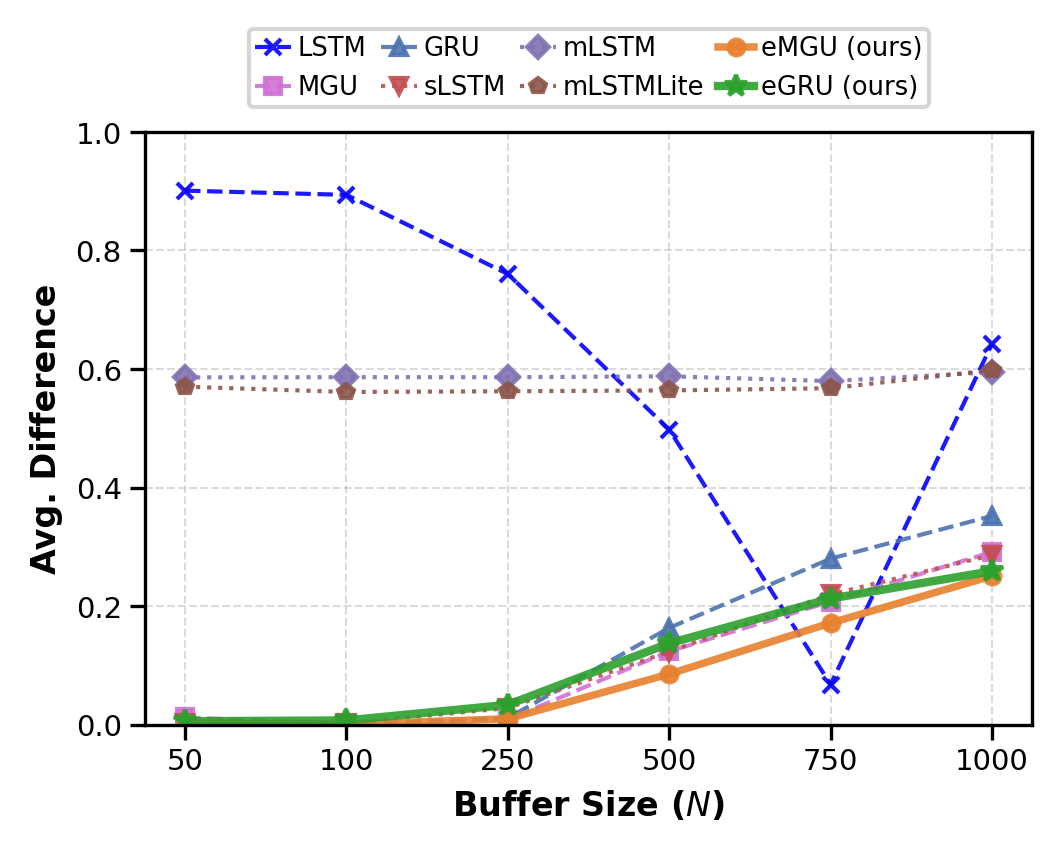

In [8]:
standard_gru = [
    0.0023514851950809804,
     0.0002784653506841105,
     0.011138614073469498,
     0.16314975496861014,
     0.27998144083684035,
      0.3520420854634578
]

standard_lstm = [
    0.9008522900668058,
     0.893750011920929,
     0.7602272900668058,
     0.4977272857319225,
     0.06761363758282228,
      0.6426136493682861
]


egru = [
    0.0057240100254738096,
     0.007054455571411418,
     0.03341584216047189,
     0.13709777423945985,
     0.212654706865254,
      0.2589108949840659
]

magru = [
    0.003032178274531028,
     0.00034034653972502395,
     0.009746287322354198,
     0.08527227900553458,
     0.17144183475192232,
      0.25077351927757263
]

MGU = [
    0.01197401014396386,
     0.0012066832001293355,
     0.008323019926002857,
     0.12348391270578497,
     0.20764233031780413,
      0.2912747588488135
]

sLSTM = [
    0.003496287192337879,
     0.0021967822247839506,
     0.02793935693035105,
     0.12329826939224016,
     0.21955445880937105,
      0.28604579871833913
]

mLSTM = [
  0.5857673381814862,
   0.5861695668484905,
   0.5860767435319353,
   0.587654715717429,
   0.5795173370602107,
    0.5946472892076662
]
mLSTMLite = [
 0.5701423370011962,
  0.561169563838751,
  0.5623762492496188,
  0.5638613978234848,
  0.5675123891617992,
   0.5980198132519675
]


import matplotlib.pyplot as plt
import numpy as np

# Data

buffer_sizes = ["50", "100", "250", "500", "750", "1000"]

# --- Single Column Plot Dimensions ---
fig, ax = plt.subplots(figsize=(3.4, 2.7), dpi=300)

# (Label, Data, Color, Marker, Linestyle, LineWidth)
# "Our approach" models get thicker solid lines to naturally stand out
models = [
    ("LSTM", standard_lstm, "#0400FF", "x", "--", 1.0),
    ("MGU", MGU, "#D071D3", "s", "--", 1.0),
    ("GRU", standard_gru, "#4C72B0", "^", "--", 1.0),
    ("sLSTM", sLSTM, "#C44E52", "v", ":", 1.0),
    ("mLSTM", mLSTM, "#8172B2", "D", ":", 1.0),
    ("mLSTMLite", mLSTMLite, "#8C564B", "p", ":", 1.0),
    ("eMGU (ours)", magru, "#E7812E", "o", "-", 1.8),
    ("eGRU (ours)", egru, "#2CA02C", "*", "-", 2.0),
]

x = np.arange(len(buffer_sizes))

for label, data, color, marker, ls, lw in models:
    ax.plot(
        x,
        data,
        label=label,
        color=color,
        marker=marker,
        markersize=3.8 if marker != "*" else 5.5,
        linestyle=ls,
        linewidth=lw,
        alpha=0.9,
    )

# --- Axes & Labels ---
ax.set_xlabel("Buffer Size ($N$)", fontsize=8, fontweight="bold", labelpad=3)
ax.set_ylabel("Avg. Difference", fontsize=8, fontweight="bold", labelpad=3)

ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=7.5)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis="both", labelsize=7, pad=2)

ax.grid(True, linestyle="--", alpha=0.45, linewidth=0.5)

# --- 2-Row x 4-Column Compact Top Legend ---
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    fontsize=6.2,
    frameon=True,
    handlelength=1.4,
    handletextpad=0.25,
    columnspacing=0.55,
    borderpad=0.25,
)

plt.tight_layout(pad=0.2)
plt.savefig("retention_line_1col.pdf", bbox_inches="tight")
plt.show()